## Вводные по кейсу

# Описание данных

## Таблица `Users`

| Поле              | Описание                                       |
|-------------------|------------------------------------------------|
| `user_id`         | Уникальный идентификатор пользователя.         |
| `registration_date` | Дата регистрации пользователя.                |
| `age`             | Возраст пользователя.                          |
| `gender`          | Пол.                                |
| `region`          | Регион.                                        |
| `acq_channel`     | Канал привлечения.                             |
| `buyer_segment`   | Сегмент покупателя.                            |
| `cohort_week`     | Неделя привлечения.|
| `cohort_month`    | Месяц привлечения. |

---

## Таблица `Events`

| Поле          | Описание                                                                 |
|---------------|--------------------------------------------------------------------------|
| `event_id`    | Уникальный идентификатор события.                                        |
| `user_id`     | Идентификатор пользователя.                                              |
| `event_date`  | Дата события.                                                            |
| `event_type`  | Тип события.   |
| `os`          | Операционная система.               |
| `device`      | Тип устройства.                                |
| `product_name`| Наименование товара, к которому относится событие (если применимо).      |
| `event_week`  | Неделя события.                                          |
| `event_month` | Месяц события .                                           |

---

## Таблица `Orders`

| Поле          | Описание                                                                 |
|---------------|--------------------------------------------------------------------------|
| `order_id`    | Уникальный идентификатор заказа.                                         |
| `user_id`     | Идентификатор пользователя, который сделал заказ |
| `order_date`  | Дата и время оформления заказа.                                          |
| `product_name`| Наименование товара.                                                     |
| `quantity`    | Количество единиц товара в заказе.                                       |
| `unit_price`  | Цена за одну единицу товара.                                             |
| `total_price` | Итоговая сумма заказа.                                                   |
| `category_name` | Наименование категории товара.                                         |
| `order_week`  | Неделя заказа.                                           |
| `order_month` | Месяц заказа.                                            |


## Таблица `Campaign_costs`

| Поле         | Описание                                                                 |
|--------------|--------------------------------------------------------------------------|
| `acq_channel`| Канал привлечения.  |
| `spend_month`| Месяц, в который был потрачен бюджет (отражает период, в котором были привлечены пользователи)                      |
| `budget`     | Маркетинговый бюджет (в денежном выражении), потраченный на данный канал в указанном месяце.                           |



## Описание событий

| Событие             | Описание                                                                                  |
|---------------------|-------------------------------------------------------------------------------------------|
| `page_view`         | Открытие любой страницы сайта или приложения пользователем.                                |
| `product_view`      | Просмотр страницы конкретного товара.                                                     |
| `product_click`     | Клик по товару (например, из списка товаров или на баннере).                              |
| `add_to_cart`       | Добавление товара в корзину.                                                              |
| `remove_from_cart`  | Удаление товара из корзины.                                                               |
| `search`            | Выполнение поиска по сайту или приложению.                                                |
| `filter_apply`      | Применение фильтра (например, по цене, бренду, категории).                                |
| `checkout_start`    | Начало оформления заказа (переход к оформлению корзины).                                  |
| `checkout_complete` | Завершение оформления заказа (не гарантирует покупку, покупка зависит от факта оплаты).                                          |
| `user_login`        | Вход пользователя в личный кабинет или аккаунт.                                           |
| `user_logout`       | Выход пользователя из аккаунта.                                                           |
| `wishlist_add`      | Добавление товара в список желаемого (wishlist).                                          |
| `category_view`     | Просмотр страницы категории товаров.                                                      |
| `banner_click`      | Клик по рекламному баннеру на сайте или в приложении.                                     |
| `promo_view`        | Просмотр промо-акции или специального предложения.                                        |


## Выручка маркетплейса = 5% от total_price

# Блок кода и расчета метрик

In [1]:
import pandas as pd
import numpy as np
import scipy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
from IPython.display import display
from statsmodels.stats.proportion import proportions_ztest
from IPython.display import display

from scipy import stats
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import t
from scipy.stats import ttest_ind

In [2]:
pa_marketplace_orders = pd.read_csv('https://code.s3.yandex.net/datasets/pa_marketplace_orders.csv', parse_dates=['order_date', 'order_week', 'order_month'])
pa_marketplace_campaign_costs = pd.read_csv('https://code.s3.yandex.net/datasets/pa_marketplace_campaign_costs.csv', parse_dates=['spend_month'])
pa_marketplace_users = pd.read_csv('https://code.s3.yandex.net/datasets/pa_marketplace_users.csv', parse_dates=['registration_date', 'cohort_week', 'cohort_month'])
pa_marketplace_events = pd.read_csv('https://code.s3.yandex.net/datasets/pa_marketplace_events.csv', parse_dates=['event_date', 'event_week', 'event_month'])

**Предобработка данных**

*Orders*

In [3]:
display(pa_marketplace_orders.head())
display(pa_marketplace_orders.info())
display(pa_marketplace_orders.category_name.unique())
display(pa_marketplace_orders.duplicated().sum())
display(pa_marketplace_orders['order_id'].duplicated().sum())

,order_id,user_id,order_date,product_name,quantity,unit_price,total_price,category_name,order_week,order_month
0,1,3,2024-01-19 01:52:52,Шуруповерт,2,5539.13,11078.26,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
1,2,3,2024-01-19 01:52:52,Молоток слесарный,1,11340.38,11340.38,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
2,3,3,2024-01-19 01:52:52,Секатор садовый,2,10892.09,21784.18,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
3,4,3,2024-01-25 13:59:38,Шуруповерт,2,5539.13,11078.26,Инструменты и садовый инвентарь,2024-01-22,2024-01-01
4,5,3,2024-01-25 13:59:38,Чай черный,1,2099.59,2099.59,Продукты питания,2024-01-22,2024-01-01


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31357 entries, 0 to 31356
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       31357 non-null  int64         
 1   user_id        31357 non-null  int64         
 2   order_date     31357 non-null  datetime64[ns]
 3   product_name   31357 non-null  object        
 4   quantity       31357 non-null  int64         
 5   unit_price     31357 non-null  float64       
 6   total_price    31357 non-null  float64       
 7   category_name  31357 non-null  object        
 8   order_week     31357 non-null  datetime64[ns]
 9   order_month    31357 non-null  datetime64[ns]
dtypes: datetime64[ns](3), float64(2), int64(3), object(2)
memory usage: 2.4+ MB


None

array(['Инструменты и садовый инвентарь', 'Продукты питания',
       'Женская одежда', 'Аксессуары для гаджетов', 'Одежда для спорта',
       'Декор и освещение', 'Детская одежда', 'Детские игрушки',
       'Книги и канцтовары', 'Медицинские товары',
       'Косметика и парфюмерия', 'Товары для туризма',
       'Сумки и аксессуары', 'Автотовары', 'Обувь мужская',
       'Обувь женская', 'Мужская одежда', 'Бытовая техника', 'Зоотовары',
       'Товары для кухни', 'Средства для ухода', 'Мебель для дома',
       'Спортивный инвентарь', 'Товары для новорожденных',
       'Украшения и часы'], dtype=object)

0

0

В данных по заказам были приведены типы временных данных к datetime64.   
Данные хорошего качества, пропусков нет, явных/неявных дубликатов тоже нет.

*Costs*

In [4]:
display(pa_marketplace_campaign_costs.head())
display(pa_marketplace_campaign_costs.info())
display(pa_marketplace_campaign_costs.acq_channel.unique())
display(pa_marketplace_campaign_costs.duplicated().sum())

,Unnamed: 0,acq_channel,spend_month,budget
0,0,Affiliate,2024-01-01,179343.3875
1,1,Affiliate,2024-02-01,175488.4875
2,2,Affiliate,2024-03-01,164543.4750
3,3,Affiliate,2024-04-01,186869.9750
4,4,Affiliate,2024-05-01,166443.7750


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88 entries, 0 to 87
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Unnamed: 0   88 non-null     int64         
 1   acq_channel  88 non-null     object        
 2   spend_month  88 non-null     datetime64[ns]
 3   budget       88 non-null     float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 2.9+ KB


None

array(['Affiliate', 'Direct', 'Email Marketing', 'Social Media',
       'Google Ads', 'SEO', 'TikTok'], dtype=object)

0

В данных по рекламным бюджетам были приведены типы временных данных к datetime64.   
Данные хорошего качества, пропусков нет, явных/неявных дубликатов тоже нет.

In [5]:
display(pa_marketplace_users.head())
display(pa_marketplace_users.info())
display(pa_marketplace_users.region.unique())
display(pa_marketplace_users.buyer_segment.unique())
display(pa_marketplace_users.gender.unique())
display(pa_marketplace_users.duplicated().sum())
display(pa_marketplace_users['user_id'].duplicated().sum())

,user_id,registration_date,age,gender,region,acq_channel,buyer_segment,cohort_week,cohort_month
0,1,2024-01-01 00:47:00,35,M,Москва,Google Ads,regular,2024-01-01,2024-01-01
1,2,2024-01-01 19:01:00,53,M,Москва,Email Marketing,rare,2024-01-01,2024-01-01
2,3,2024-01-01 04:13:00,66,F,Санкт-Петербург,Google Ads,regular,2024-01-01,2024-01-01
3,4,2024-01-01 17:18:00,58,M,Краснодар,Affiliate,one_time,2024-01-01,2024-01-01
4,5,2024-01-01 08:29:00,58,F,Другие регионы,Google Ads,regular,2024-01-01,2024-01-01


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44151 entries, 0 to 44150
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            44151 non-null  int64         
 1   registration_date  44151 non-null  datetime64[ns]
 2   age                44151 non-null  int64         
 3   gender             44151 non-null  object        
 4   region             44151 non-null  object        
 5   acq_channel        44151 non-null  object        
 6   buyer_segment      44151 non-null  object        
 7   cohort_week        44151 non-null  datetime64[ns]
 8   cohort_month       44151 non-null  datetime64[ns]
dtypes: datetime64[ns](3), int64(2), object(4)
memory usage: 3.0+ MB


None

array(['Москва', 'Санкт-Петербург', 'Краснодар', 'Другие регионы',
       'Нижний Новгород', 'Екатеринбург', 'Московская область',
       'Новосибирск', 'Ростов-на-Дону'], dtype=object)

array(['regular', 'rare', 'one_time', 'medium'], dtype=object)

array(['M', 'F'], dtype=object)

0

0

В данных по пользователям были приведены типы временных данных к datetime64.   
Данные хорошего качества, пропусков нет, явных/неявных дубликатов тоже нет.

In [6]:
display(pa_marketplace_events.head())
display(pa_marketplace_events.info())
display(pa_marketplace_events.event_type.unique())
display(pa_marketplace_events.os.unique())
display(pa_marketplace_events.duplicated().sum())

,event_id,user_id,event_date,event_type,os,device,product_name,event_week,event_month
0,3132,100,2024-01-01,page_view,iOS,mobile,NaN,2024-01-01,2024-01-01
1,3133,100,2024-01-01,product_view,iOS,mobile,Шорты для тренировок,2024-01-01,2024-01-01
2,3134,100,2024-01-01,product_click,iOS,mobile,Куртка детская,2024-01-01,2024-01-01
3,3135,100,2024-01-01,add_to_cart,iOS,mobile,Балетки классические,2024-01-01,2024-01-01
4,3136,100,2024-01-01,checkout_start,iOS,mobile,NaN,2024-01-01,2024-01-01


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 785859 entries, 0 to 785858
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   event_id      785859 non-null  int64         
 1   user_id       785859 non-null  int64         
 2   event_date    785859 non-null  datetime64[ns]
 3   event_type    785859 non-null  object        
 4   os            785859 non-null  object        
 5   device        785859 non-null  object        
 6   product_name  385740 non-null  object        
 7   event_week    785859 non-null  datetime64[ns]
 8   event_month   785859 non-null  datetime64[ns]
dtypes: datetime64[ns](3), int64(2), object(4)
memory usage: 54.0+ MB


None

array(['page_view', 'product_view', 'product_click', 'add_to_cart',
       'checkout_start', 'checkout_complete', 'user_logout', 'search',
       'category_view', 'filter_apply', 'promo_view', 'wishlist_add',
       'user_login', 'banner_click', 'remove_from_cart'], dtype=object)

array(['iOS', 'Windows', 'macOS', 'Android'], dtype=object)

0

В данных по событиям были приведены типы временных данных к datetime64.   
Данные хорошего качества, есть null значения в поле `product_name` - это объясняется спицификой данных, явных/неявных дубликатов тоже нет.

### 2. Построить обзор ключевых метрик

На этом этапе вам нужно выполнить верхнеуровневую оценку состояния продукта с помощью собранных витрин. Бизнес просит просто оценить текущее состояние — без глубокой сегментации и оценки сложных метрик.

Выручка бизнеса — 5% комиссии от стоимости любой продажи.

Посмотрите на общую динамику ключевых метрик: например, Revenue, ARPU или ARPPU, MAU, WAU, DAU, AOV, Retention, CTR, CR в заказ. Следовать этому списку необязательно, исходите из данных.

Ваша цель — быстро получить целостную картину, не применяя сегментацию и не рассматривая глубокие срезы. Определите, соответствует ли продукт базовым ожиданиям, виден ли рост, есть ли тревожные сигналы.

Результатом задания будет ваш вывод о динамике основных продуктовых метрик.

**Revenue**

,order_month,revenue
0,2024-01-01,6.488900e+05
1,2024-02-01,1.296557e+06
2,2024-03-01,1.940750e+06
3,2024-04-01,2.142838e+06
4,2024-05-01,2.478758e+06
5,2024-06-01,2.106012e+06
6,2024-07-01,2.446535e+06
7,2024-08-01,2.465802e+06
8,2024-09-01,1.935367e+06
9,2024-10-01,1.716108e+06


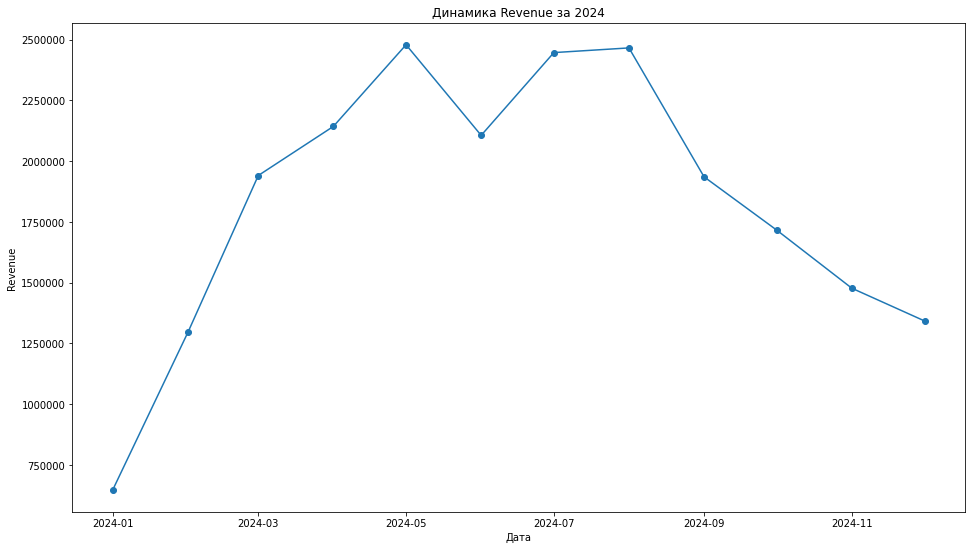

In [7]:
pa_marketplace_orders['revenue'] = pa_marketplace_orders['total_price']*0.05

week_revenue_df = pa_marketplace_orders.groupby('order_month')['revenue'].sum().reset_index()

display(week_revenue_df)

plt.figure(figsize=(16,9))
plt.plot(week_revenue_df['order_month'], week_revenue_df['revenue'], marker='o')
plt.title('Динамика Revenue за 2024')
plt.xlabel('Дата')
plt.ylabel('Revenue')
plt.ticklabel_format(style='plain', axis='y')
plt.show()

Выручка демонстрирует выраженную сезонность: после слабого начала года наблюдается устойчивый рост с января по июнь-июль, где достигается пик, затем начинается постепенное снижение, переходящее в заметный спад к концу года. При этом в течение всего периода присутствует волатильность с регулярными колебаниями, а декабрь выделяется резким падением, что может указывать либо на сезонный фактор, либо на неполные данные.

**ARPPU**

,order_month,total_users,revenue,ARPPU
0,2024-01-01,454,6.488900e+05,1429.273186
1,2024-02-01,839,1.296557e+06,1545.359964
2,2024-03-01,1165,1.940750e+06,1665.879652
3,2024-04-01,1324,2.142838e+06,1618.458002
4,2024-05-01,1404,2.478758e+06,1765.497223
5,2024-06-01,1230,2.106012e+06,1712.204761
6,2024-07-01,1385,2.446535e+06,1766.451591
7,2024-08-01,1385,2.465802e+06,1780.362741
8,2024-09-01,1163,1.935367e+06,1664.115819
9,2024-10-01,999,1.716108e+06,1717.826082


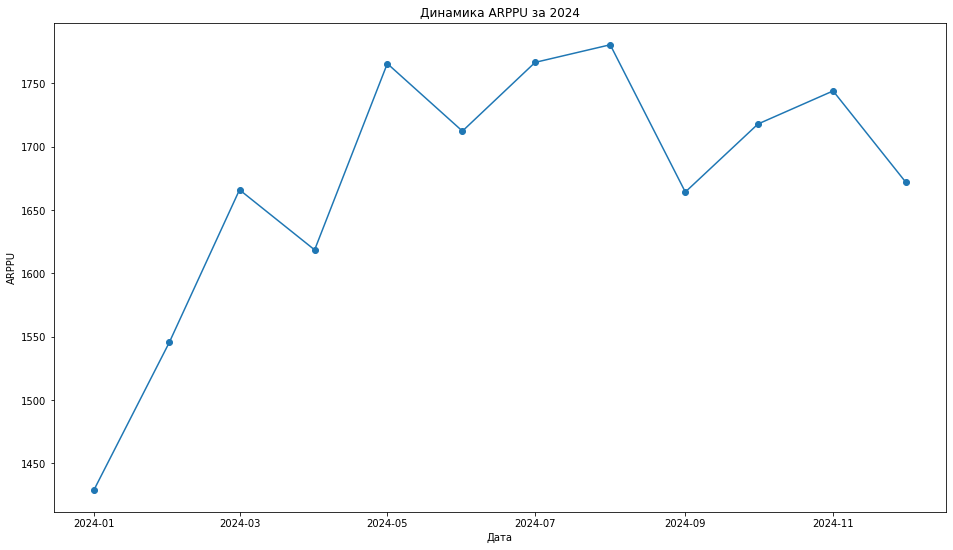

In [8]:
month_arppu_df = pa_marketplace_orders.groupby('order_month').agg(
    total_users=('user_id', 'nunique'),
    revenue=('revenue', 'sum')).reset_index()

month_arppu_df['ARPPU'] = month_arppu_df['revenue'] / month_arppu_df['total_users']

display(month_arppu_df)

plt.figure(figsize=(16,9))
plt.plot(month_arppu_df['order_month'], month_arppu_df['ARPPU'], marker='o')
plt.title('Динамика ARPPU за 2024')
plt.xlabel('Дата')
plt.ylabel('ARPPU')
plt.ticklabel_format(style='plain', axis='y')
plt.show()

ARPPU демонстрирует умеренный рост в первой половине года с пиком в летние месяцы, что указывает на увеличение среднего чека платящих пользователей, после чего наблюдаются колебания без выраженного тренда, а к концу года - незначительное снижение, при этом в целом метрика остается относительно стабильной без резких провалов.

**MAU**

,event_month,active_users
0,2024-01-01,1149
1,2024-02-01,2162
2,2024-03-01,2844
3,2024-04-01,3059
4,2024-05-01,3310
5,2024-06-01,3174
6,2024-07-01,3481
7,2024-08-01,3861
8,2024-09-01,3744
9,2024-10-01,3581


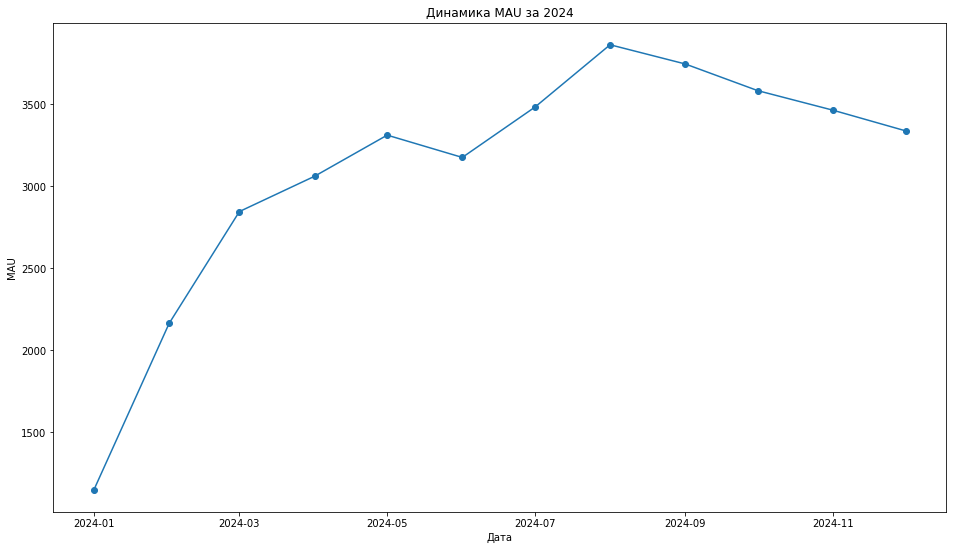

In [9]:
month_dau_df = pa_marketplace_events.groupby('event_month')['user_id'].nunique().reset_index(name='active_users')

display(month_dau_df)

plt.figure(figsize=(16,9))
plt.plot(month_dau_df['event_month'], month_dau_df['active_users'], marker='o')
plt.title('Динамика MAU за 2024')
plt.xlabel('Дата')
plt.ylabel('MAU')
plt.ticklabel_format(style='plain', axis='y')
plt.show()

MAU демонстрирует уверенный рост в первой половине года с пиком в летние месяцы, что указывает на активное привлечение или возврат пользователей, после чего начинается постепенное снижение, однако показатели остаются выше начала года, что говорит о сохранении части привлеченной аудитории несмотря на спад активности к концу года.

**AOV**

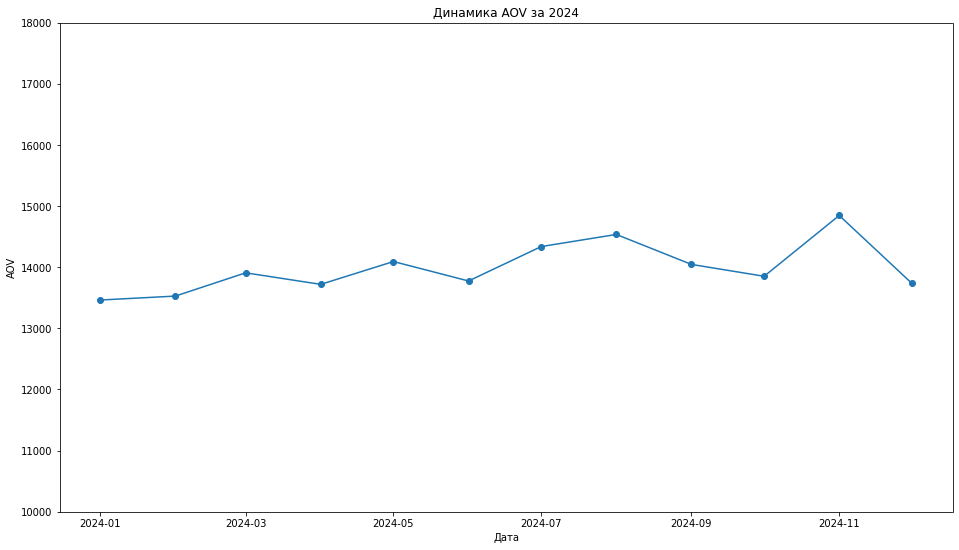

In [10]:
month_aov_df = pa_marketplace_orders.groupby('order_month').agg(
    total_orders=('order_id', 'count'),
    total_price=('total_price', 'sum')).reset_index()

month_aov_df['AOV'] = month_aov_df['total_price'] / month_aov_df['total_orders']

plt.figure(figsize=(16,9))
plt.plot(month_aov_df['order_month'], month_aov_df['AOV'], marker='o')
plt.title('Динамика AOV за 2024')
plt.xlabel('Дата')
plt.ylabel('AOV')
plt.ylim(10000, 18000)
plt.ticklabel_format(style='plain', axis='y')
plt.show()

AOV в 2024 году в целом рос умеренно, без резких провалов: с января по август наблюдается постепенное увеличение, затем в сентябре-октябре есть небольшое снижение, в ноябре достигается пик за год, после чего в декабре показатель снова снижается. В целом динамика выглядит стабильной с положительным трендом

**Retention**

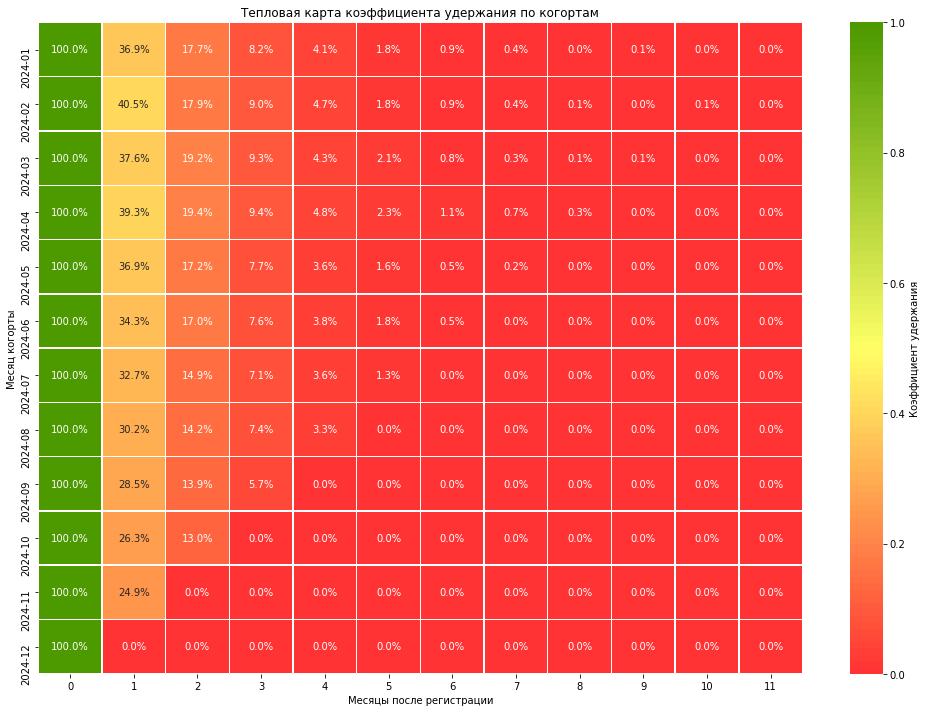

In [11]:
cmap = mcolors.LinearSegmentedColormap.from_list('green_red', ['#FF3333', '#FFFF66', '#4C9900'], N=100)

cohort_sizes = (
    pa_marketplace_users.groupby('cohort_month', as_index=False)
    .agg(cohort_size=('user_id', 'nunique'))
)

events = (
    pa_marketplace_users[['user_id', 'cohort_month']]
    .merge(pa_marketplace_events[['user_id', 'event_month']], on='user_id')
)

events['cohort_month'] = pd.to_datetime(events['cohort_month']).dt.to_period('M')
events['event_month'] = pd.to_datetime(events['event_month']).dt.to_period('M')
events['n_period'] = (events['event_month'] - events['cohort_month']).apply(lambda x: x.n)

activity = (
    events[events['n_period'] > 0]
    .groupby(['cohort_month', 'n_period'], as_index=False)
    .agg(active_users=('user_id', 'nunique'))
)

base = cohort_sizes.copy()
base['cohort_month'] = pd.to_datetime(base['cohort_month']).dt.to_period('M')
base['n_period'] = 0
base['active_users'] = base['cohort_size']

# display(base)

retention = pd.concat([
    base[['cohort_month', 'n_period', 'active_users']],
    activity
], ignore_index=True)

# display(retention.head(20))

retention = retention.merge(
    base[['cohort_month', 'cohort_size']].drop_duplicates(),
    on='cohort_month',
    how='left'
)
  
# display(retention.head(30))    
    
retention['retention_rate'] = retention['active_users'] / retention['cohort_size']

retention_pivot = retention.pivot(
    index='cohort_month',
    columns='n_period',
    values='retention_rate'
).fillna(0)

plt.figure(figsize=(14, 10))
sns.heatmap(
    retention_pivot,
    annot=True,
    fmt='.1%',
    cmap=cmap,
    linewidths=0.5,
    cbar_kws={'label': 'Коэффициент удержания'}
)
plt.title('Тепловая карта коэффициента удержания по когортам')
plt.ylabel('Месяц когорты')
plt.xlabel('Месяцы после регистрации')
plt.tight_layout()
plt.show()

Тепловая карта показывает типичную для продукта картину резкого снижения retention после первого месяца: из 100% пользователей в месяц регистрации ко второму месяцу обычно сохраняется около 25–40%, к третьему — примерно 13–19%, а дальше удержание быстро снижается до однозначных значений и к 6–9 месяцу почти обнуляется. Наиболее сильное удержание видно у когорт начала года, особенно у февраля–апреля, тогда как у более поздних когорт показатели первого и второго месяцев заметно слабее, что может указывать на ухудшение качества привлечения, продукта или сезонный эффект во второй половине года.

**Conversion**  
Классическая воронка

In [12]:
pa_marketplace_events['event_type'].unique()

array(['page_view', 'product_view', 'product_click', 'add_to_cart',
       'checkout_start', 'checkout_complete', 'user_logout', 'search',
       'category_view', 'filter_apply', 'promo_view', 'wishlist_add',
       'user_login', 'banner_click', 'remove_from_cart'], dtype=object)

In [13]:
funnel_events=['page_view', 'product_view', 'product_click','add_to_cart', 'checkout_start', 'checkout_complete']

In [14]:
funnel_events_df = pa_marketplace_events[pa_marketplace_events['event_type'].isin(funnel_events)]
funnel_events_df = funnel_events_df.groupby('event_type')['user_id'].nunique().reindex(funnel_events).reset_index()

orders = pd.DataFrame({
    'event_type': ['purchase'],
    'user_id': [pa_marketplace_orders['user_id'].nunique()]
})

funnel_result = pd.concat([funnel_events_df, orders], ignore_index=True)
funnel_result['CR'] = round( funnel_result['user_id'] / funnel_result.iloc[0]['user_id'] * 100,2 )
funnel_result

,event_type,user_id,CR
0,page_view,22098,100.00
1,product_view,22069,99.87
2,product_click,21745,98.40
3,add_to_cart,20411,92.37
4,checkout_start,16769,75.88
5,checkout_complete,13897,62.89
6,purchase,8922,40.37


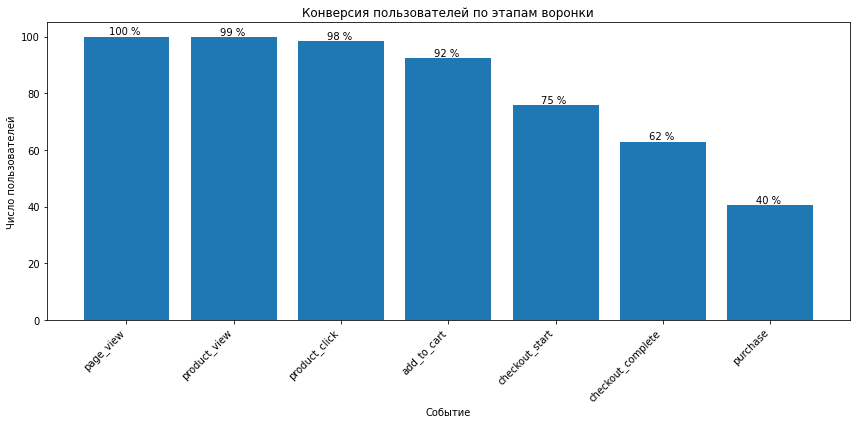

In [15]:
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(funnel_result['event_type'], funnel_result['CR'])

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{int(height)} % ',
        ha='center',
        va='bottom'
    )

plt.xticks(rotation=45, ha='right')
ax.set_title('Конверсия пользователей по этапам воронки')
ax.set_xlabel('Событие')
ax.set_ylabel('Число пользователей')
plt.tight_layout()
plt.show()

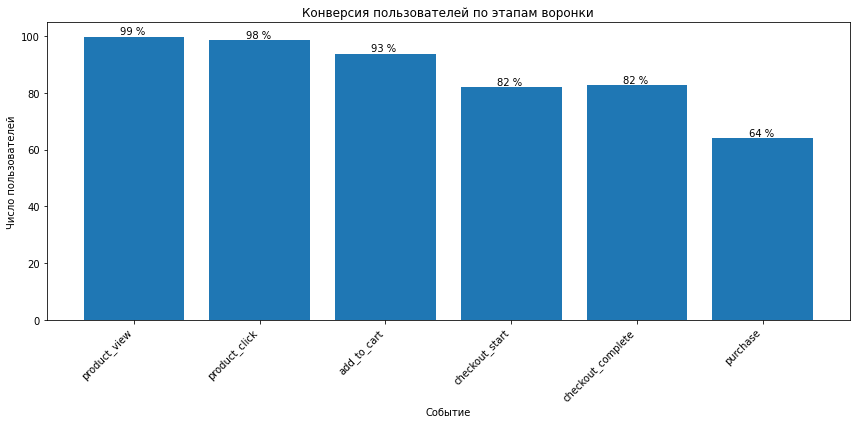

In [16]:
funnel_result['sbs'] = round(funnel_result['user_id'] / funnel_result['user_id'].shift() * 100, 2)
funnel_result = funnel_result.dropna()

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(funnel_result['event_type'], funnel_result['sbs'])

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{int(height)} % ',
        ha='center',
        va='bottom'
    )

plt.xticks(rotation=45, ha='right')
ax.set_title('Конверсия пользователей по этапам воронки')
ax.set_xlabel('Событие')
ax.set_ylabel('Число пользователей')
plt.tight_layout()
plt.show()

Классическая и step-by-step воронки показывают стандартное поведение метрики конверсии по этапам. На классической воронке виден показатель конверсии в целевое действие - 40%, это хороший показатель, но чтобы дать более точную оценку показателя стоит провести сравнительный анализ с предыдущими годами(если есть данные) и сравнить с показателями конкурентов на рынке.  
Step-by-step воронка демонстрирует адекватные показатели - провалы не наблюдаются

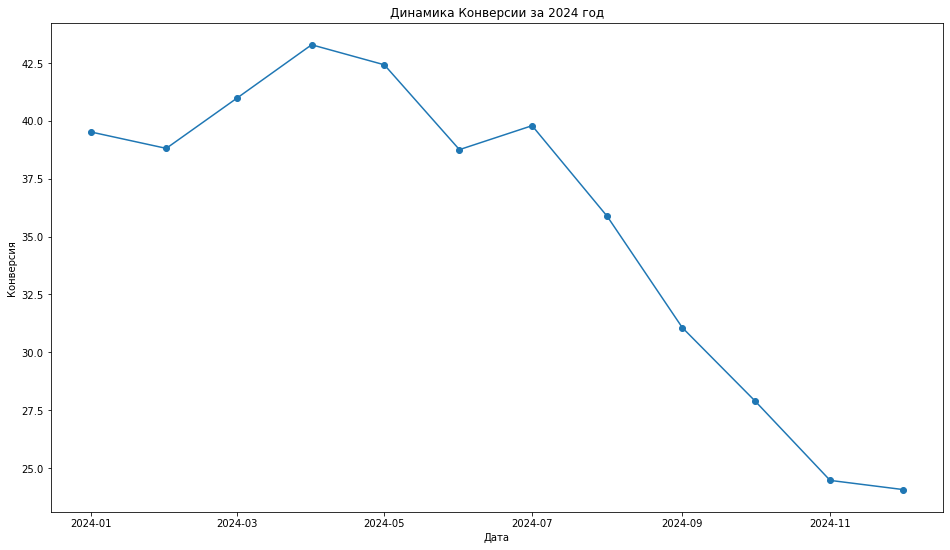

In [17]:
active_users = pa_marketplace_events.groupby('event_month')['user_id'].nunique().reset_index(name='active_users')
payed_users = pa_marketplace_orders.groupby('order_month')['user_id'].nunique().reset_index(name='payed_users')
month_conversion = pd.merge (active_users, payed_users, left_on='event_month', right_on='order_month', how='left')
month_conversion['conversion_rate'] = month_conversion['payed_users'] / month_conversion['active_users']*100

month_conversion.head()

plt.figure(figsize=(16,9))
plt.plot(month_conversion['order_month'], month_conversion['conversion_rate'], marker='o')
plt.title('Динамика Конверсии за 2024 год')
plt.xlabel('Дата')
plt.ylabel('Конверсия')
plt.ticklabel_format(style='plain', axis='y')
plt.show()

Конверсия росла в первой половине года и достигла пика весной, после чего начала снижаться. Во второй половине года спад заметно ускорился, и к концу года показатель опустился почти вдвое от пиковых значений, что указывает на ухудшение эффективности во второй половине 2024 года. Следует подробнее изучть причины снижения метрики.

### 3. Оценка метрик монетизации и юнит-экономики

Выполните анализ монетизации. Определите, сколько зарабатывает продукт и сколько тратит на привлечение.

Важны как агрегированные метрики (ARPU, AOV), так и показатели эффективности (CAC, ROI, Payback Period).

Сформулируйте первые выводы по результатам анализа метрик. Сделайте это в формате записки для заказчика. Изложите все основные результаты так, чтобы прослеживалась связь между мыслями. Не пишите много - заказчик не будет читать записку полностью, а просто просмотрит.

Напишите выводы в конце блока, чтобы заказчик мог быстро ознакомиться с основными результатами.

In [18]:
monthly_df = pa_marketplace_orders.groupby('order_month').agg(
    monthly_revenue=('revenue', 'sum'),
    total_sales=('total_price', 'sum'),
    order_users=('user_id', 'nunique')
    ).reset_index()
monthly_df.columns = ['month', 'monthly_revenue', 'total_sales','order_users']
user_counts_df = pa_marketplace_users.groupby('cohort_month')['user_id'].nunique().reset_index()
user_counts_df.columns = ['month', 'total_users']
monthly_df = pd.merge(monthly_df, user_counts_df, on='month', how='left')
monthly_df

,month,monthly_revenue,total_sales,order_users,total_users
0,2024-01-01,6.488900e+05,12977800.53,454,2985
1,2024-02-01,1.296557e+06,25931140.19,839,2711
2,2024-03-01,1.940750e+06,38814995.89,1165,2965
3,2024-04-01,2.142838e+06,42856767.90,1324,2905
4,2024-05-01,2.478758e+06,49575162.02,1404,3066
5,2024-06-01,2.106012e+06,42120237.13,1230,2810
6,2024-07-01,2.446535e+06,48930709.06,1385,4388
7,2024-08-01,2.465802e+06,49316047.93,1385,4431
8,2024-09-01,1.935367e+06,38707333.94,1163,4466
9,2024-10-01,1.716108e+06,34322165.12,999,4440


In [19]:
monthly_costs = pa_marketplace_campaign_costs.groupby('spend_month')['budget'].sum().reset_index()
monthly_costs.columns = ['month', 'cost']

monthly_df = pd.merge(monthly_df, monthly_costs, on='month', how='left')

monthly_df['CAC'] = monthly_df['cost'] / monthly_df['total_users']

monthly_df['LTV'] = monthly_df['monthly_revenue'] / monthly_df['total_users']

monthly_df['ROI'] = (monthly_df['LTV'] - monthly_df['CAC']) / monthly_df['CAC'] * 100

monthly_df

,month,monthly_revenue,total_sales,order_users,total_users,cost,CAC,LTV,ROI
0,2024-01-01,6.488900e+05,12977800.53,454,2985,1.177457e+06,394.457945,217.383593,-44.890553
1,2024-02-01,1.296557e+06,25931140.19,839,2711,1.061386e+06,391.510856,478.257842,22.156981
2,2024-03-01,1.940750e+06,38814995.89,1165,2965,1.167680e+06,393.821373,654.553050,66.205568
3,2024-04-01,2.142838e+06,42856767.90,1324,2905,1.147740e+06,395.091194,737.638002,86.700694
4,2024-05-01,2.478758e+06,49575162.02,1404,3066,1.225322e+06,399.648493,808.466439,102.294379
5,2024-06-01,2.106012e+06,42120237.13,1230,2810,1.130440e+06,402.291733,749.470412,86.300227
6,2024-07-01,2.446535e+06,48930709.06,1385,4388,1.776447e+06,404.841979,557.551379,37.720743
7,2024-08-01,2.465802e+06,49316047.93,1385,4431,1.811678e+06,408.864309,556.488918,36.106015
8,2024-09-01,1.935367e+06,38707333.94,1163,4466,1.820719e+06,407.684467,433.355732,6.296846
9,2024-10-01,1.716108e+06,34322165.12,999,4440,1.810803e+06,407.838417,386.510868,-5.229411


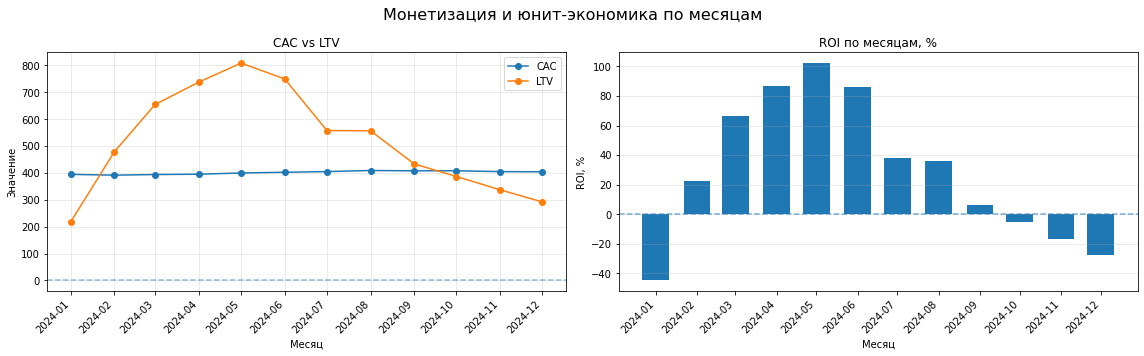

In [20]:
import matplotlib.dates as mdates

monthly_df['month'] = pd.to_datetime(monthly_df['month'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Монетизация и юнит-экономика по месяцам', fontsize=16)

axes[0].plot(monthly_df['month'], monthly_df['CAC'], marker='o', label='CAC')
axes[0].plot(monthly_df['month'], monthly_df['LTV'], marker='o', label='LTV')
axes[0].set_title('CAC vs LTV')
axes[0].set_xlabel('Месяц')
axes[0].set_ylabel('Значение')
axes[0].axhline(0, linestyle='--', alpha=0.5)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].bar(monthly_df['month'], monthly_df['ROI'], width=20)
axes[1].set_title('ROI по месяцам, %')
axes[1].set_xlabel('Месяц')
axes[1].set_ylabel('ROI, %')
axes[1].axhline(0, linestyle='--', alpha=0.6)
axes[1].grid(True, axis='y', alpha=0.3)

for ax in axes.flat:
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

График показывает, что в первой половине 2024 года LTV уверенно превышал CAC, благодаря чему ROI быстро рос и достиг пика в мае, после чего началось постепенное ухудшение юнит-экономики. Во второй половине года LTV снижался, в сентябре почти сравнялся с CAC, а с октября опустился ниже него, из-за чего ROI ушёл сначала к околонулевым, а затем и к отрицательным значениям в конце года. В целом это означает, что в начале года привлечение было эффективным и окупаемым, а к концу года маркетинговая эффективность заметно снизилась. Следует обратить внимание на причины падения LTV и роста неэффективности привлечения во второй половине года.

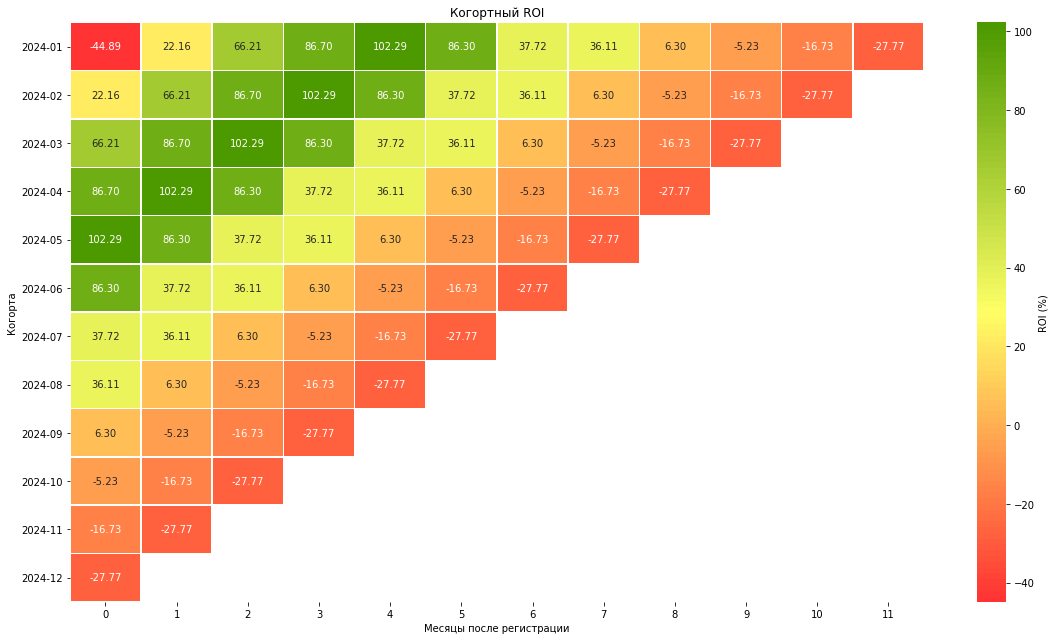

In [21]:
cmap = mcolors.LinearSegmentedColormap.from_list('green_red', ['#FF3333', '#FFFF66', '#4C9900'], N=100)
monthly_df['month'] = pd.to_datetime(monthly_df['month'])

num_cohorts = len(monthly_df)
num_periods = num_cohorts

roi_cohort = np.full((num_cohorts, num_periods), np.nan)

for i in range(num_cohorts):
    for j in range(num_periods):
        if i + j < num_cohorts:
            roi_cohort[i, j] = monthly_df['ROI'].iloc[i + j]


cohort_labels = monthly_df['month'].dt.strftime('%Y-%m').values
period_labels = list(range(num_periods))

plt.figure(figsize=(16, 9))

sns.heatmap(
    roi_cohort,
    annot=True,
    fmt='.2f',
    cmap=cmap,
    linewidths=0.5,
    xticklabels=period_labels,
    yticklabels=cohort_labels,
    cbar_kws={'label': 'ROI (%)'}
)

plt.title('Когортный ROI')
plt.xlabel('Месяцы после регистрации')
plt.ylabel('Когорта')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Когортный ROI был сильным у когорт начала года, но у более поздних когорт заметно ухудшался и к концу года стал отрицательным уже с первых месяцев. Это говорит о снижении окупаемости привлечения во второй половине 2024 года. Следует обратить внимание на каналы и сегменты, которые дали отрицательный ROI в конце года.

# Выводы по этапам 2 и 3

## 1. AOV - средний чек

**Что показывает метрика:**  
AOV отражает среднюю сумму заказа и помогает понять, сколько выручки в среднем приносит одна покупка.

**Что видно по данным:**  
В течение 2024 года AOV в целом оставался стабильным с умеренным восходящим трендом. В начале года показатель находился примерно на уровне **13.4-13.9 тыс.**, затем постепенно рос и в июле-августе достиг **14.3-14.5 тыс.** Максимум наблюдается в **ноябре - около 14.9 тыс.**, после чего в декабре произошло снижение примерно до **13.7 тыс.**. Это означает, что даже при ухудшении части других метрик ценность одной покупки в среднем не снижалась, а в отдельные месяцы даже росла. Следует обратить внимание на факторы ноябрьского пика, чтобы понять, можно ли масштабировать этот эффект.

## 2. Retention — удержание пользователей по когортам

**Что показывает метрика:**  
Retention показывает, какая доля пользователей возвращается через 1, 2, 3 и более месяцев после регистрации. Это один из ключевых индикаторов качества продукта и привлеченного трафика.

**Что видно по данным:**  
Во всех когортах наблюдается резкое снижение удержания уже после первого месяца. У когорт начала года retention первого месяца составлял примерно **36.9-40.5%**, второго - **17.7-19.4%**, третьего - **7.7-9.4%**. Далее показатель быстро снижается до однозначных значений: к 5-6 месяцу удержание в большинстве когорт находится около **0.5-2.3%**, а затем практически обнуляется. При этом у когорт второй половины года retention первого месяца ухудшается: с **40.5%** в феврале до **24.9%** в ноябре, а у декабря следующего месяца еще нет. Это указывает на ухудшение качества новых пользователей или продукта во второй половине года. Следует обратить внимание на причины падения первого месяца удержания у поздних когорт.

## 3. Конверсия по этапам воронки

**Что показывает метрика:**  
Воронка отражает, какая доля пользователей проходит ключевые этапы пути от просмотра страницы до покупки.

**Что видно по данным:**  
Верхняя часть воронки работает очень хорошо:

- `page_view` - **100%**
- `product_view` - **99%**
- `product_click` - **98%**

То есть на первых этапах потери минимальны. Основные потери начинаются ниже:

- `add_to_cart` - **92%**
- `checkout_start` - **75%**
- `checkout_complete` - **62%**
- `purchase` - **40%**

Самое заметное снижение происходит между `add_to_cart` и `purchase`: суммарно теряется более половины пользователей, уже проявивших высокий интерес к товару. Значит, ключевая проблема находится не в интересе к продукту, а в процессе оформления заказа и завершения покупки. Следует обратить внимание на этапы checkout и purchase как на главные точки потерь.

## 4. Общая динамика конверсии за 2024 год

**Что показывает метрика:**  
Эта метрика показывает, как менялась итоговая конверсия в ключевое действие во времени.

**Что видно по данным:**  
В начале года конверсия держалась на хорошем уровне — около **38.8-39.5%** в январе-феврале. Затем был рост до **41.0%** в марте и пик примерно **43.3%** в апреле, после чего в мае показатель оставался высоким - около **42.4%**. Начиная с июня тренд развернулся вниз.  
Иными словами, от весеннего пика до конца года конверсия снизилась примерно на **19 п.п.** Это существенное ухудшение эффективности, особенно во второй половине года. Следует обратить внимание на изменения после июля: именно в этот период началось устойчивое проседание конверсии.

## 5. CAC, LTV и ROI по месяцам

**Что показывают метрики:**

- **CAC** - стоимость привлечения клиента
- **LTV** - ценность клиента за жизненный цикл
- **ROI** - окупаемость инвестиций в привлечение

### CAC

CAC в течение года был относительно стабильным и колебался примерно в диапазоне **395-410**. Существенного роста стоимости привлечения не наблюдается, то есть основная проблема не в том, что маркетинг стал резко дороже. Следует обратить внимание не столько на CAC, сколько на эффективность монетизации после привлечения.

### LTV

LTV рос в первой половине года:

- январь - около **220**
- февраль - около **480**
- март - около **655**
- апрель - около **740**
- май - пик около **810**
- июнь - около **750**

После июня началось выраженное снижение:

- июль-август - около **555**
- сентябрь - около **435**
- октябрь - около **385**
- ноябрь - около **335**
- декабрь - около **295**

Во второй половине года LTV быстро ухудшается и в конце года уже становится ниже CAC. Следует обратить внимание на причины падения LTV во второй половине года.

### ROI

ROI по месяцам подтверждает эту картину:

- январь - **-44.89%**
- февраль - **22.16%**
- март - **66.21%**
- апрель - **86.70%**
- май - **102.29%**
- июнь - **86.30%**
- июль - **37.72%**
- август - **36.11%**
- сентябрь - **6.30%**
- октябрь - **-5.23%**
- ноябрь - **-16.73%**
- декабрь - **-27.77%**

Самый сильный период - апрель-июнь, когда ROI был **86.30-102.29%**. С сентября окупаемость почти исчезла, а в четвертом квартале перешла в минус. Следует обратить внимание на то, почему при стабильном CAC бизнес перестал окупать привлечение в конце года.

## 6. Когортный ROI

**Что показывает метрика:**  
Когортный ROI помогает понять, как окупаются пользователи, привлеченные в конкретный месяц, по мере их "старения".

**Что видно по данным:**  
Когорты начала года выглядели сильнее.
Но более поздние когорты заметно слабее
Это показывает, что поздние когорты изначально заходили в экономику гораздо слабее и не успевали выйти на приемлемый уровень окупаемости.

---

# Итоговый вывод

По совокупности метрик 2024 год разделяется на две очень разные части. В первой половине года бизнес выглядел здорово: конверсия росла с **39.5%** в январе до пика **43.3%** в апреле, LTV достигал **около 810** в мае, ROI выходил на **102.29%**, а когортный ROI у ранних когорт быстро становился положительным и высоким. При этом AOV оставался стабильным и рос от **около 13.5 тыс.** в начале года до **около 14.9 тыс.** в ноябре.

Во второй половине года началось ухудшение сразу по нескольким направлениям. Retention первого месяца снизился примерно с **40.5%** у февральской когорты до **24.9%** у ноябрьской. Общая конверсия упала с весенних **42-43%** до **24.1%** в декабре. Основные потери сосредоточены в нижней части воронки: при **98%** на этапе `product_click` итоговая конверсия в `purchase` составляет только **40%**. LTV к декабрю снизился примерно до **290**, при том что CAC остался на уровне **около 405**, из-за чего ROI стал отрицательным: **-5.23%** в октябре, **-16.73%** в ноябре и **-27.77%** в декабре. Когортный ROI поздних когорт также быстро уходил в минус уже с первых месяцев.

Следует в первую очередь обратить внимание на причины падения конверсии и LTV после июля, потому что именно они сильнее всего ухудшили экономику бизнеса к концу года.

## 4. Поиск инсайтов, точек роста и сегментация


После того как вы провели верхнеуровневую оценку данных, самое время переходить от общей картины к точечным наблюдениям. Посмотрите вглубь данных: по каналам,
сегментам пользователей, категориям товаров, регионам, типам устройств. Ищите
закономерности, различия, аномалии.

Цель — сформировать обоснованные гипотезы:

* какие сегменты работают лучше остальных
* какие сегменты работают хуже остальных
* на каких этапах воронки теряются пользователи
* какие группы можно или нужно масштабировать
* куда стоит инвестировать больше внимания или ресурсов

По итогам анализа также:

* сформулируйте в виде аналитической записки выводы
* сформулируйте несколько гипотез, которые помогут развить продукт. Например: «Если предлагать клиентам на iOS персонализированные скидки, то они станут чаще конвертировать в продукт». При формулировании гипотез опишите, на что вы опираетесь при её формировании. Например, на динамику метрики или на взаимосвязь метрик.

Напишите выводы в конце блока, чтобы заказчик мог быстро ознакомиться с основными результатами.
Отправьте работу на проверку ревьюеру. Ревьюер будет проверять корректность выводов и гипотез, а не сам код расчета, поэтому проверьте, что у вас есть выводы по каждому из блоков в предназначенном для этого месте.
После завершения ревью вы получите от ревьюера новые вводные и задачу от бизнеса.


Проведем сегментацию

In [22]:
orders = pa_marketplace_orders.copy()
costs = pa_marketplace_campaign_costs.copy()
users = pa_marketplace_users.copy()
events = pa_marketplace_events.copy()

In [23]:
display(orders.head())
display(users.head())

,order_id,user_id,order_date,product_name,quantity,unit_price,total_price,category_name,order_week,order_month,revenue
0,1,3,2024-01-19 01:52:52,Шуруповерт,2,5539.13,11078.26,Инструменты и садовый инвентарь,2024-01-15,2024-01-01,553.9130
1,2,3,2024-01-19 01:52:52,Молоток слесарный,1,11340.38,11340.38,Инструменты и садовый инвентарь,2024-01-15,2024-01-01,567.0190
2,3,3,2024-01-19 01:52:52,Секатор садовый,2,10892.09,21784.18,Инструменты и садовый инвентарь,2024-01-15,2024-01-01,1089.2090
3,4,3,2024-01-25 13:59:38,Шуруповерт,2,5539.13,11078.26,Инструменты и садовый инвентарь,2024-01-22,2024-01-01,553.9130
4,5,3,2024-01-25 13:59:38,Чай черный,1,2099.59,2099.59,Продукты питания,2024-01-22,2024-01-01,104.9795


,user_id,registration_date,age,gender,region,acq_channel,buyer_segment,cohort_week,cohort_month
0,1,2024-01-01 00:47:00,35,M,Москва,Google Ads,regular,2024-01-01,2024-01-01
1,2,2024-01-01 19:01:00,53,M,Москва,Email Marketing,rare,2024-01-01,2024-01-01
2,3,2024-01-01 04:13:00,66,F,Санкт-Петербург,Google Ads,regular,2024-01-01,2024-01-01
3,4,2024-01-01 17:18:00,58,M,Краснодар,Affiliate,one_time,2024-01-01,2024-01-01
4,5,2024-01-01 08:29:00,58,F,Другие регионы,Google Ads,regular,2024-01-01,2024-01-01


In [24]:
orders_users = pd.merge(orders, users, on='user_id', how='left')
orders_users.drop(columns=['order_week', 'order_month', 'registration_date', 'cohort_week', 'cohort_month'], inplace=True)
display(orders_users.head())

,order_id,user_id,order_date,product_name,quantity,unit_price,total_price,category_name,revenue,age,gender,region,acq_channel,buyer_segment
0,1,3,2024-01-19 01:52:52,Шуруповерт,2,5539.13,11078.26,Инструменты и садовый инвентарь,553.9130,66.0,F,Санкт-Петербург,Google Ads,regular
1,2,3,2024-01-19 01:52:52,Молоток слесарный,1,11340.38,11340.38,Инструменты и садовый инвентарь,567.0190,66.0,F,Санкт-Петербург,Google Ads,regular
2,3,3,2024-01-19 01:52:52,Секатор садовый,2,10892.09,21784.18,Инструменты и садовый инвентарь,1089.2090,66.0,F,Санкт-Петербург,Google Ads,regular
3,4,3,2024-01-25 13:59:38,Шуруповерт,2,5539.13,11078.26,Инструменты и садовый инвентарь,553.9130,66.0,F,Санкт-Петербург,Google Ads,regular
4,5,3,2024-01-25 13:59:38,Чай черный,1,2099.59,2099.59,Продукты питания,104.9795,66.0,F,Санкт-Петербург,Google Ads,regular


Наиболее прибыльные

In [25]:
monthly_orders_users = orders_users.groupby('category_name').agg(
    revenue=('revenue','sum'),
    total_price=('total_price', 'sum'),
    users=('user_id','nunique'),
    orders=('order_id','nunique')).reset_index().sort_values(by='revenue', ascending=False)

display(monthly_orders_users.head(3))
display(monthly_orders_users.tail(3))

,category_name,revenue,total_price,users,orders
11,Мебель для дома,3.580998e+06,71619964.45,514,979
2,Бытовая техника,2.248933e+06,44978661.11,546,1030
24,Украшения и часы,1.718297e+06,34365942.06,495,1024


,category_name,revenue,total_price,users,orders
4,Детская одежда,321305.3030,6426106.06,942,1421
9,Книги и канцтовары,204443.4370,4088868.74,739,1316
19,Средства для ухода,163270.0065,3265400.13,648,1172


In [26]:
#Наиболее и наименее часто покупаемые
display(monthly_orders_users.sort_values(by='orders', ascending=False).head(3))
display(monthly_orders_users.sort_values(by='orders', ascending=False).tail(3))


,category_name,revenue,total_price,users,orders
17,Продукты питания,596447.694,11928953.88,2659,4027
4,Детская одежда,321305.303,6426106.06,942,1421
7,Зоотовары,372583.964,7451679.28,888,1396


,category_name,revenue,total_price,users,orders
12,Медицинские товары,3.410835e+05,6821669.13,542,980
11,Мебель для дома,3.580998e+06,71619964.45,514,979
23,Товары для туризма,1.137318e+06,22746355.71,498,970


In [27]:
orders_users.groupby('gender')['user_id'].nunique().reset_index()

,gender,user_id
0,F,4381
1,M,4273


Равное распределение

In [28]:
orders_users.groupby('gender')['order_id'].nunique().reset_index()

,gender,order_id
0,F,15455
1,M,14991


Тоже примерно равное распределение

In [29]:
orders_users.groupby('region')['user_id'].nunique().reset_index().sort_values(by='user_id', ascending=False)

,region,user_id
0,Другие регионы,2816
3,Москва,2200
8,Санкт-Петербург,1317
4,Московская область,681
1,Екатеринбург,418
5,Нижний Новгород,354
6,Новосибирск,310
2,Краснодар,290
7,Ростов-на-Дону,268


Москва, Московская область и Санкт-Петербург занимают лидирующие позиции по количеству пользователей

In [30]:
orders_users.head()

,order_id,user_id,order_date,product_name,quantity,unit_price,total_price,category_name,revenue,age,gender,region,acq_channel,buyer_segment
0,1,3,2024-01-19 01:52:52,Шуруповерт,2,5539.13,11078.26,Инструменты и садовый инвентарь,553.9130,66.0,F,Санкт-Петербург,Google Ads,regular
1,2,3,2024-01-19 01:52:52,Молоток слесарный,1,11340.38,11340.38,Инструменты и садовый инвентарь,567.0190,66.0,F,Санкт-Петербург,Google Ads,regular
2,3,3,2024-01-19 01:52:52,Секатор садовый,2,10892.09,21784.18,Инструменты и садовый инвентарь,1089.2090,66.0,F,Санкт-Петербург,Google Ads,regular
3,4,3,2024-01-25 13:59:38,Шуруповерт,2,5539.13,11078.26,Инструменты и садовый инвентарь,553.9130,66.0,F,Санкт-Петербург,Google Ads,regular
4,5,3,2024-01-25 13:59:38,Чай черный,1,2099.59,2099.59,Продукты питания,104.9795,66.0,F,Санкт-Петербург,Google Ads,regular


**Воронки**

In [31]:
funnel_events_df = pd.merge(events, users, on='user_id', how='left')
funnel_events_df.drop(columns=['registration_date', 'cohort_week','event_date', 'product_name', 'event_week','event_month'], inplace=True)
funnel_events_df.head()

,event_id,user_id,event_type,os,device,age,gender,region,acq_channel,buyer_segment,cohort_month
0,3132,100,page_view,iOS,mobile,39.0,M,Другие регионы,Affiliate,regular,2024-01-01
1,3133,100,product_view,iOS,mobile,39.0,M,Другие регионы,Affiliate,regular,2024-01-01
2,3134,100,product_click,iOS,mobile,39.0,M,Другие регионы,Affiliate,regular,2024-01-01
3,3135,100,add_to_cart,iOS,mobile,39.0,M,Другие регионы,Affiliate,regular,2024-01-01
4,3136,100,checkout_start,iOS,mobile,39.0,M,Другие регионы,Affiliate,regular,2024-01-01


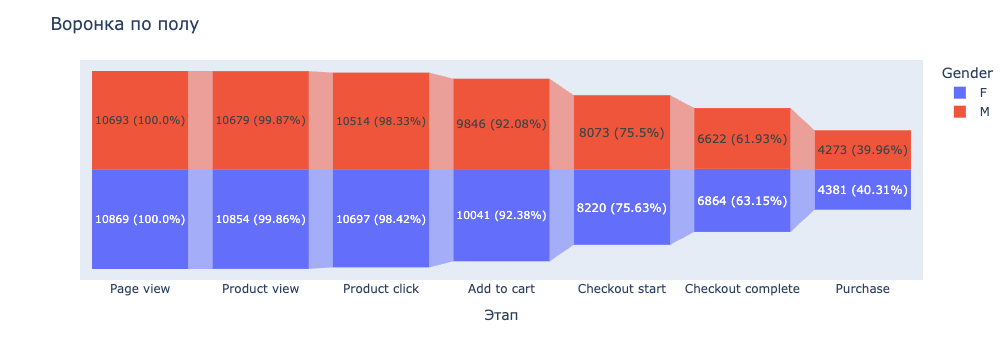

In [32]:
import plotly.express as px

funnel_events = [
    'page_view', 'product_view', 'product_click',
    'add_to_cart', 'checkout_start', 'checkout_complete', 'purchase'
]

stage_labels = {
    'page_view': 'Page view',
    'product_view': 'Product view',
    'product_click': 'Product click',
    'add_to_cart': 'Add to cart',
    'checkout_start': 'Checkout start',
    'checkout_complete': 'Checkout complete',
    'purchase': 'Purchase'
}

funnel_df = funnel_events_df[funnel_events_df['event_type'].isin(funnel_events)]
funnel_df = funnel_df.groupby(['event_type', 'gender'])['user_id'].nunique().reset_index()

orders_df = orders_users.groupby('gender')['user_id'].nunique().reset_index()
orders_df['event_type'] = 'purchase'

funnel_result = pd.concat([funnel_df, orders_df], ignore_index=True)

funnel_result['event_type'] = pd.Categorical(
    funnel_result['event_type'],
    categories=funnel_events,
    ordered=True
)

funnel_result = funnel_result.sort_values(['event_type', 'gender']).reset_index(drop=True)

funnel_result['CR'] = (
    funnel_result['user_id']
    / funnel_result.groupby('gender')['user_id'].transform('first')
    * 100
).round(2)

plot_df = funnel_result.copy()
plot_df['stage'] = plot_df['event_type'].map(stage_labels)
plot_df['label'] = plot_df['user_id'].astype(str) + ' (' + plot_df['CR'].astype(str) + '%)'

fig = px.funnel(
    plot_df,
    x='stage',
    y='user_id',
    color='gender',
    category_orders={'stage': list(stage_labels.values())},
    text='label'
)

fig.update_traces(texttemplate='%{text}')
fig.update_layout(
    title='Воронка по полу',
    xaxis_title='Этап',
    yaxis_title='Количество пользователей',
    legend_title='Gender'
)

fig.show()

Воронка по полу почти одинаковая: мужчины и женщины проходят верхние этапы одинаково, а основные потери у обеих групп происходят на этапе оформления заказа. Женщины конвертируются в покупку немного лучше: 40.31% против 39.96% у мужчин. Следует обратить внимание на нижнюю часть воронки, а не на различия по полу.

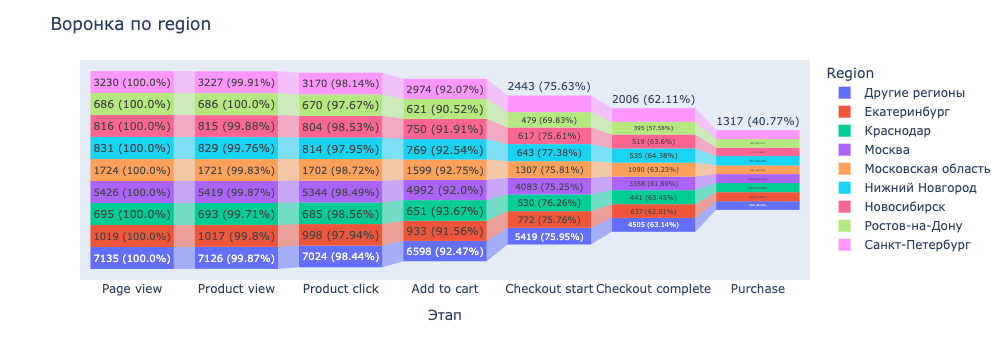

In [33]:
import plotly.express as px

funnel_events = [
    'page_view', 'product_view', 'product_click',
    'add_to_cart', 'checkout_start', 'checkout_complete', 'purchase'
]

stage_labels = {
    'page_view': 'Page view',
    'product_view': 'Product view',
    'product_click': 'Product click',
    'add_to_cart': 'Add to cart',
    'checkout_start': 'Checkout start',
    'checkout_complete': 'Checkout complete',
    'purchase': 'Purchase'
}

funnel_df = funnel_events_df[funnel_events_df['event_type'].isin(funnel_events)]
funnel_df = funnel_df.groupby(['event_type', 'region'])['user_id'].nunique().reset_index()

orders_df = orders_users.groupby('region')['user_id'].nunique().reset_index()
orders_df['event_type'] = 'purchase'

funnel_result = pd.concat([funnel_df, orders_df], ignore_index=True)

funnel_result['event_type'] = pd.Categorical(
    funnel_result['event_type'],
    categories=funnel_events,
    ordered=True
)

funnel_result = funnel_result.sort_values(['event_type', 'region']).reset_index(drop=True)

funnel_result['CR'] = (
    funnel_result['user_id']
    / funnel_result.groupby('region')['user_id'].transform('first')
    * 100
).round(2)

plot_df = funnel_result.copy()
plot_df['stage'] = plot_df['event_type'].map(stage_labels)
plot_df['label'] = plot_df['user_id'].astype(str) + ' (' + plot_df['CR'].astype(str) + '%)'

fig = px.funnel(
    plot_df,
    x='stage',
    y='CR',
    color='region',
    category_orders={'stage': list(stage_labels.values())},
    text='label'
)

fig.update_traces(texttemplate='%{text}')
fig.update_layout(
    title='Воронка по region',
    xaxis_title='Этап',
    yaxis_title='Количество пользователей',
    legend_title='Region'
)

fig.show()

Воронка по регионам в целом выглядит похожей: основные потери начинаются после add_to_cart и усиливаются на этапах checkout_start–purchase. В целом различия между регионами есть, но они не критические, поэтому проблема скорее общая для нижней части воронки, чем локальная для одного города. Можно обратить внимание на регионы с наименьшей финальной конверсией и сравнить их checkout-путь с лидирующими регионами.

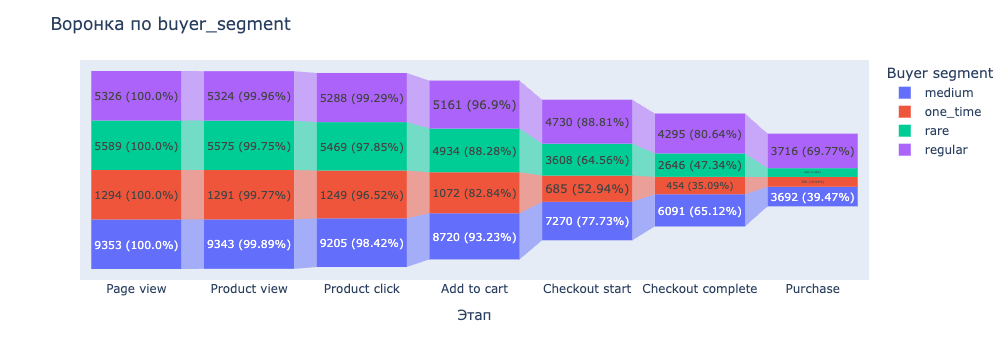

In [34]:
import plotly.express as px

funnel_events = [
    'page_view', 'product_view', 'product_click',
    'add_to_cart', 'checkout_start', 'checkout_complete', 'purchase'
]

stage_labels = {
    'page_view': 'Page view',
    'product_view': 'Product view',
    'product_click': 'Product click',
    'add_to_cart': 'Add to cart',
    'checkout_start': 'Checkout start',
    'checkout_complete': 'Checkout complete',
    'purchase': 'Purchase'
}

funnel_df = funnel_events_df[funnel_events_df['event_type'].isin(funnel_events)]
funnel_df = funnel_df.groupby(['event_type', 'buyer_segment'])['user_id'].nunique().reset_index()

orders_df = orders_users.groupby('buyer_segment')['user_id'].nunique().reset_index()
orders_df['event_type'] = 'purchase'

funnel_result = pd.concat([funnel_df, orders_df], ignore_index=True)

funnel_result['event_type'] = pd.Categorical(
    funnel_result['event_type'],
    categories=funnel_events,
    ordered=True
)

funnel_result = funnel_result.sort_values(['event_type', 'buyer_segment']).reset_index(drop=True)

funnel_result['CR'] = (
    funnel_result['user_id']
    / funnel_result.groupby('buyer_segment')['user_id'].transform('first')
    * 100
).round(2)

plot_df = funnel_result.copy()
plot_df['stage'] = plot_df['event_type'].map(stage_labels)
plot_df['label'] = plot_df['user_id'].astype(str) + ' (' + plot_df['CR'].astype(str) + '%)'

fig = px.funnel(
    plot_df,
    x='stage',
    y='CR',
    color='buyer_segment',
    category_orders={'stage': list(stage_labels.values())},
    text='label'
)

fig.update_traces(texttemplate='%{text}')
fig.update_layout(
    title='Воронка по buyer_segment',
    xaxis_title='Этап',
    yaxis_title='Количество пользователей',
    legend_title='Buyer segment'
)

fig.show()

Воронка по `buyer_segment` показывает сильные различия между сегментами: лучше всего проходят путь до покупки regular-покупатели с итоговой конверсией 69.77%, тогда как medium дают 39.47%, а one_time - лишь 19.94%, у rare - вообще 17.68%. Основные потери у слабых сегментов начинаются уже после add_to_cart и резко усиливаются на этапах checkout, тогда как у regular пользователей воронка заметно устойчивее. Следует отдельно проанализировать причины низкой конверсии у `one_time` и `rare сегментов`, так как именно они сильнее всего просаживают итоговую эффективность.

In [35]:
orders_users = orders_users.merge(events[['user_id', 'os', 'device']], on='user_id', how='left')
orders_users.head()

,order_id,user_id,order_date,product_name,quantity,unit_price,total_price,category_name,revenue,age,gender,region,acq_channel,buyer_segment,os,device
0,1,3,2024-01-19 01:52:52,Шуруповерт,2,5539.13,11078.26,Инструменты и садовый инвентарь,553.913,66.0,F,Санкт-Петербург,Google Ads,regular,Android,mobile
1,1,3,2024-01-19 01:52:52,Шуруповерт,2,5539.13,11078.26,Инструменты и садовый инвентарь,553.913,66.0,F,Санкт-Петербург,Google Ads,regular,Android,mobile
2,1,3,2024-01-19 01:52:52,Шуруповерт,2,5539.13,11078.26,Инструменты и садовый инвентарь,553.913,66.0,F,Санкт-Петербург,Google Ads,regular,Android,mobile
3,1,3,2024-01-19 01:52:52,Шуруповерт,2,5539.13,11078.26,Инструменты и садовый инвентарь,553.913,66.0,F,Санкт-Петербург,Google Ads,regular,Android,mobile
4,1,3,2024-01-19 01:52:52,Шуруповерт,2,5539.13,11078.26,Инструменты и садовый инвентарь,553.913,66.0,F,Санкт-Петербург,Google Ads,regular,Android,mobile


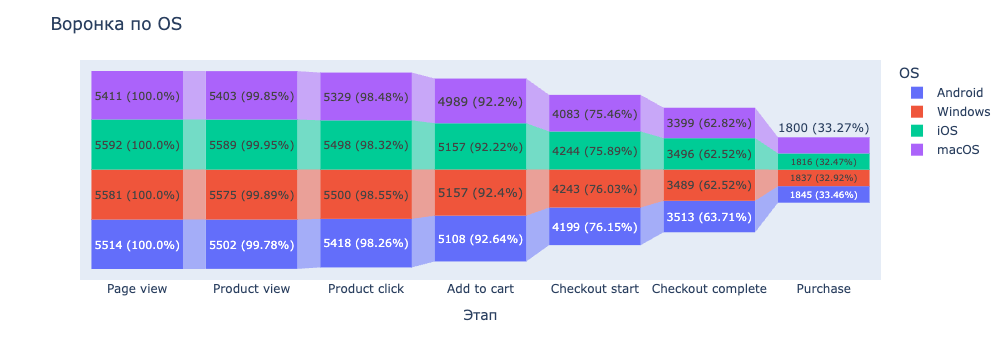

In [36]:
import plotly.express as px

funnel_events = [
    'page_view', 'product_view', 'product_click',
    'add_to_cart', 'checkout_start', 'checkout_complete', 'purchase'
]

stage_labels = {
    'page_view': 'Page view',
    'product_view': 'Product view',
    'product_click': 'Product click',
    'add_to_cart': 'Add to cart',
    'checkout_start': 'Checkout start',
    'checkout_complete': 'Checkout complete',
    'purchase': 'Purchase'
}

funnel_df = funnel_events_df[funnel_events_df['event_type'].isin(funnel_events)]
funnel_df = funnel_df.groupby(['event_type', 'os'])['user_id'].nunique().reset_index()

orders_df = orders_users.groupby('os')['user_id'].nunique().reset_index()
orders_df['event_type'] = 'purchase'

funnel_result = pd.concat([funnel_df, orders_df], ignore_index=True)

funnel_result['event_type'] = pd.Categorical(
    funnel_result['event_type'],
    categories=funnel_events,
    ordered=True
)

funnel_result = funnel_result.sort_values(['event_type', 'os']).reset_index(drop=True)

funnel_result['CR'] = (
    funnel_result['user_id']
    / funnel_result.groupby('os')['user_id'].transform('first')
    * 100
).round(2)

plot_df = funnel_result.copy()
plot_df['stage'] = plot_df['event_type'].map(stage_labels)
plot_df['label'] = plot_df['user_id'].astype(str) + ' (' + plot_df['CR'].astype(str) + '%)'

fig = px.funnel(
    plot_df,
    x='stage',
    y='user_id',
    color='os',
    category_orders={'stage': list(stage_labels.values())},
    text='label'
)

fig.update_traces(texttemplate='%{text}')
fig.update_layout(
    title='Воронка по OS',
    xaxis_title='Этап',
    yaxis_title='Количество пользователей',
    legend_title='OS'
)

fig.show()

Воронка по OS почти одинаковая для всех платформ: различия минимальны, а основные потери у всех начинаются на этапе checkout. Немного лучше итоговая конверсия у Android - 33.46%, немного слабее у iOS - 32.47%, при этом разрыв между платформами несущественный

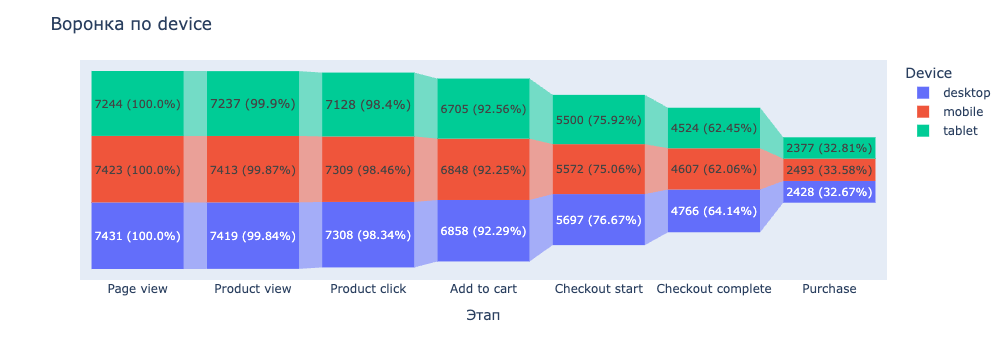

In [37]:
import plotly.express as px

funnel_events = [
    'page_view', 'product_view', 'product_click',
    'add_to_cart', 'checkout_start', 'checkout_complete', 'purchase'
]

stage_labels = {
    'page_view': 'Page view',
    'product_view': 'Product view',
    'product_click': 'Product click',
    'add_to_cart': 'Add to cart',
    'checkout_start': 'Checkout start',
    'checkout_complete': 'Checkout complete',
    'purchase': 'Purchase'
}

funnel_df = funnel_events_df[funnel_events_df['event_type'].isin(funnel_events)]
funnel_df = funnel_df.groupby(['event_type', 'device'])['user_id'].nunique().reset_index()

orders_df = orders_users.groupby('device')['user_id'].nunique().reset_index()
orders_df['event_type'] = 'purchase'

funnel_result = pd.concat([funnel_df, orders_df], ignore_index=True)

funnel_result['event_type'] = pd.Categorical(
    funnel_result['event_type'],
    categories=funnel_events,
    ordered=True
)

funnel_result = funnel_result.sort_values(['event_type', 'device']).reset_index(drop=True)

funnel_result['CR'] = (
    funnel_result['user_id']
    / funnel_result.groupby('device')['user_id'].transform('first')
    * 100
).round(2)

plot_df = funnel_result.copy()
plot_df['stage'] = plot_df['event_type'].map(stage_labels)
plot_df['label'] = plot_df['user_id'].astype(str) + ' (' + plot_df['CR'].astype(str) + '%)'

fig = px.funnel(
    plot_df,
    x='stage',
    y='user_id',
    color='device',
    category_orders={'stage': list(stage_labels.values())},
    text='label'
)

fig.update_traces(texttemplate='%{text}')
fig.update_layout(
    title='Воронка по device',
    xaxis_title='Этап',
    yaxis_title='Количество пользователей',
    legend_title='Device'
)

fig.show()

Воронка по device также для каждого устройства с минимальной разницей.

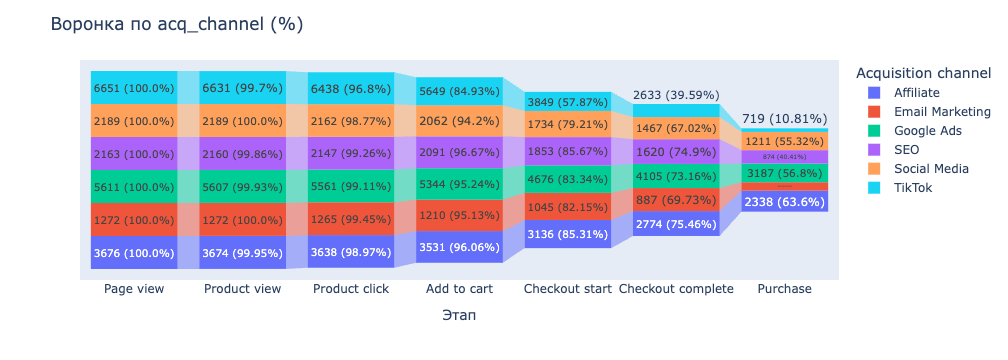

In [38]:
import plotly.express as px

funnel_events = [
    'page_view', 'product_view', 'product_click',
    'add_to_cart', 'checkout_start', 'checkout_complete', 'purchase'
]

stage_labels = {
    'page_view': 'Page view',
    'product_view': 'Product view',
    'product_click': 'Product click',
    'add_to_cart': 'Add to cart',
    'checkout_start': 'Checkout start',
    'checkout_complete': 'Checkout complete',
    'purchase': 'Purchase'
}

funnel_df = funnel_events_df[funnel_events_df['event_type'].isin(funnel_events)]
funnel_df = funnel_df.groupby(['event_type', 'acq_channel'])['user_id'].nunique().reset_index()

orders_df = orders_users.groupby('acq_channel')['user_id'].nunique().reset_index()
orders_df['event_type'] = 'purchase'

funnel_result = pd.concat([funnel_df, orders_df], ignore_index=True)

funnel_result['event_type'] = pd.Categorical(
    funnel_result['event_type'],
    categories=funnel_events,
    ordered=True
)

funnel_result = funnel_result.sort_values(['event_type', 'acq_channel']).reset_index(drop=True)

funnel_result['CR'] = (
    funnel_result['user_id']
    / funnel_result.groupby('acq_channel')['user_id'].transform('first')
    * 100
).round(2)

plot_df = funnel_result.copy()
plot_df['stage'] = plot_df['event_type'].map(stage_labels)
plot_df['label'] = (
    plot_df['user_id'].astype(str) + ' (' + plot_df['CR'].astype(str) + '%)'
)

fig = px.funnel(
    plot_df,
    x='stage',
    y='CR',
    color='acq_channel',
    category_orders={'stage': list(stage_labels.values())},
    text='label'
)

fig.update_traces(texttemplate='%{text}')
fig.update_layout(
    title='Воронка по acq_channel (%)',
    xaxis_title='Этап',
    yaxis_title='Конверсия, %',
    legend_title='Acquisition channel'
)

fig.show()

Воронка по каналам привлечения показывает самые заметные различия среди сегментов: лучшую итоговую конверсию в покупку дают Affiliate-63.6%, Google Ads - 56.8% и Social Media - 55.32%, тогда как слабее всего работают TikTok - 10.81% и Email Marketing - 25.55%. При этом TikTok имеет наибольшее число привлеченных пользователей при наименьшей конверсии. Следует в первую очередь пересмотреть эффективность TikTok и Email Marketing и сравнить их аудиторию с каналами-лидерами

**Затраты на рекламу**

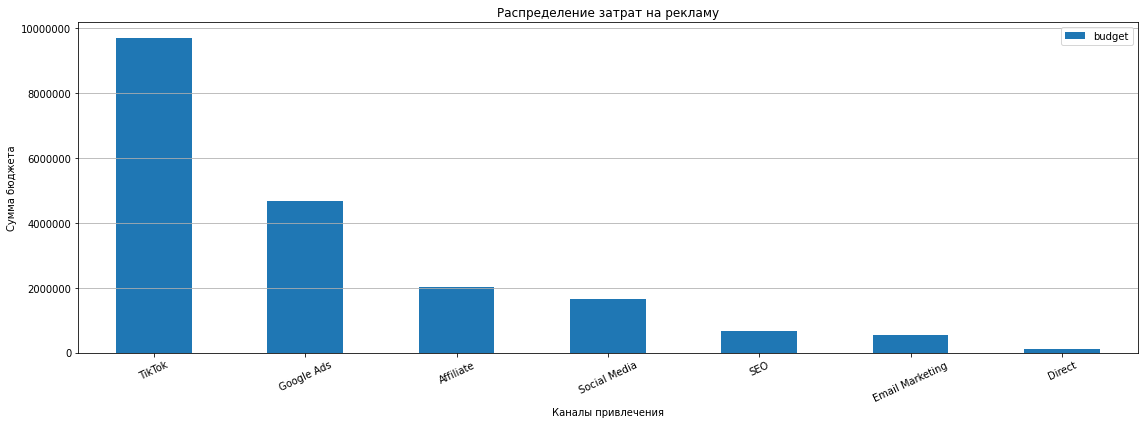

,acq_channel,budget
6,TikTok,9.695376e+06
3,Google Ads,4.663490e+06
0,Affiliate,2.012341e+06
5,Social Media,1.647396e+06
4,SEO,6.615116e+05
2,Email Marketing,5.383424e+05
1,Direct,1.087105e+05


In [39]:
from matplotlib.ticker import ScalarFormatter

acq_channel_total = costs.groupby('acq_channel')['budget'].sum().reset_index().sort_values('budget', ascending=False)

ax = acq_channel_total.plot(
    kind='bar',
    x='acq_channel',
    y='budget',
    figsize=(16, 6),
    rot=25
)

plt.title('Распределение затрат на рекламу')
plt.xlabel('Каналы привлечения')
plt.ylabel('Сумма бюджета')
plt.grid(axis='y')

ax.yaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()

display(acq_channel_total)

**Бюджеты на рекламу по месяцам**

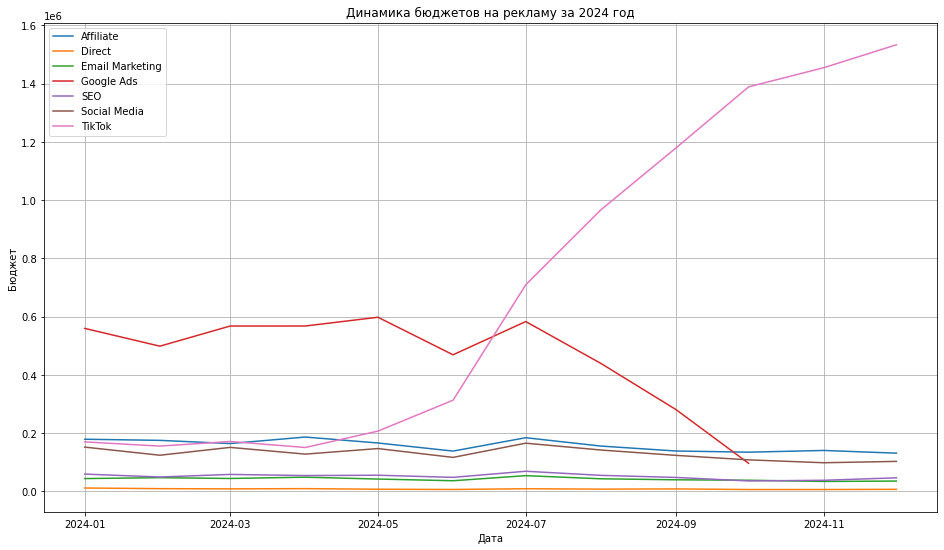

In [40]:
acq_channel_monthly = costs.groupby(['spend_month', 'acq_channel'])['budget'].sum().reset_index()
acq_channel_monthly = acq_channel_monthly[acq_channel_monthly['spend_month'] < '2025-01-01']
plt.figure(figsize=(16,9))

for channel in acq_channel_monthly['acq_channel'].unique():
    channel_df = acq_channel_monthly[acq_channel_monthly['acq_channel']==channel]
    plt.plot(channel_df['spend_month'], channel_df['budget'], label=channel)

plt.title('Динамика бюджетов на рекламу за 2024 год')
plt.xlabel('Дата')  
plt.ylabel('Бюджет')   
plt.legend()
plt.grid()

plt.show()

**Динамика привлечения пользователей по каналам**

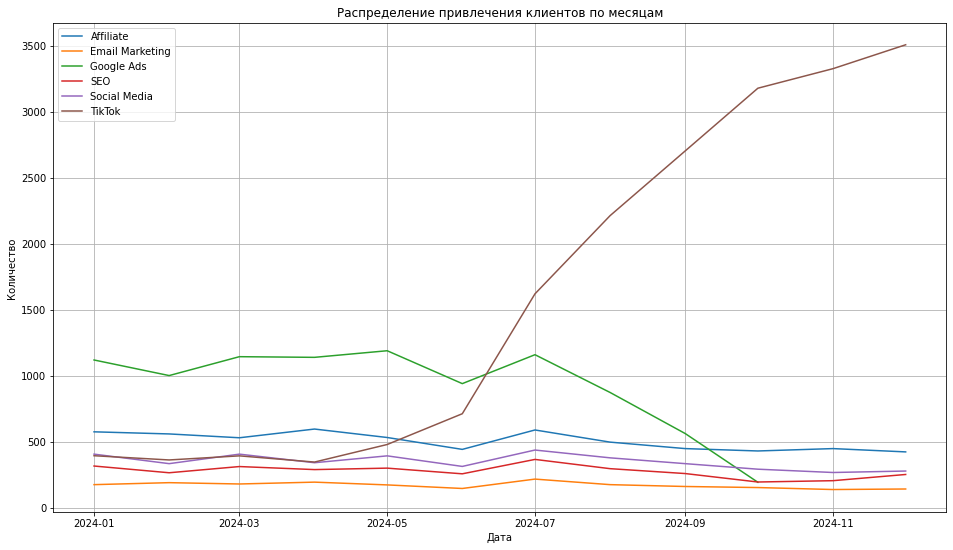

In [41]:
acq_channel_users = users.groupby(['cohort_month', 'acq_channel'])['user_id'].nunique().reset_index()

plt.figure(figsize=(16,9))

for channel in acq_channel_users['acq_channel'].unique():
    channel_df = acq_channel_users[acq_channel_users['acq_channel']==channel]
    plt.plot(channel_df['cohort_month'], channel_df['user_id'], label=channel)

plt.title('Распределение привлечения клиентов по месяцам')
plt.xlabel('Дата')  
plt.ylabel('Количество')   

plt.legend()
plt.grid()
plt.show()

По каналам привлечения видно сильное смещение бюджета в TikTok: на него приходится самый большой объем затрат — около 9.7 млн, что более чем вдвое выше Google Ads (4.66 млн) и заметно выше остальных каналов. При этом во второй половине года бюджет TikTok резко наращивался и к концу года стал доминировать, одновременно с этим именно TikTok дал самый сильный рост по объему привлеченных клиентов. Однако в предыдущем анализе воронки этот канал показывал одну из самых слабых конверсий в покупку — 10.81%, тогда как Affiliate и Google Ads работали заметно эффективнее. Это может означать, что TikTok хорошо масштабируется по трафику, но приводит менее качественную аудиторию, из-за чего рост привлечения не конвертируется в сопоставимый бизнес-результат. Следует пересмотреть эффективность TikTok, прежде чем дальше наращивать его бюджет.

# Выводы по этапу 4

## 1. Воронка по полу

**Что показывает метрика:**  
Сравнивает прохождение этапов воронки мужчинами и женщинами.

**Что видно по данным:**  
Поведение мужчин и женщин почти одинаково на всех этапах. Верхняя часть воронки проходит без существенных потерь: до `product_click` обе группы доходят почти полностью. Основное падение начинается после `add_to_cart` и усиливается на этапах `checkout_start`, `checkout_complete` и `purchase`.

Разница минимальна, то есть пол практически не влияет на итоговую эффективность воронки.

---

## 2. Воронка по регионам

**Что показывает метрика:**  
Сравнивает прохождение воронки по регионам и помогает понять, есть ли локальные различия в конверсии.

**Что видно по данным:**  
Лучшая итоговая конверсия в покупку:
- **Санкт-Петербург - 40.77%**
- **Другие регионы - 40.74%**

Слабее остальных:
- **Ростов-на-Дону - 38.78%**
- **Краснодар - 37.41%**

Разрыв между лучшими и худшими регионами есть, но он не критический. 

---

## 3. Воронка по buyer_segment

**Что показывает метрика:**  
Позволяет оценить, как разные типы покупателей проходят путь до покупки.

**Что видно по данным:**  
Это один из самых сильных сегментационных факторов в анализе. Различия между сегментами здесь заметные.

Итоговая конверсия в покупку:
- **regular - 69.77%**
- **medium - 39.47%**
- **one_time - 19.94%**

Сегмент `rare` на графике также уступает `regular` и заметно слабее проходит нижнюю часть воронки, но сильнее `one_time`.

Наиболее качественный сегмент - `regular`: он лучше проходит и этапы корзины, и checkout, и финальную покупку. Самый слабый сегмент - `one_time`, где особенно сильное падение начинается после `add_to_cart` и продолжается на всех шагах оформления. Следует отдельно исследовать поведение `one_time` и `medium`, так как именно они сильнее всего снижают итоговую конверсию.

---

## 4. Воронка по OS

**Что показывает метрика:**  
Сравнивает прохождение воронки пользователями разных операционных систем.

**Что видно по данным:**  
Различия между платформами очень небольшие. У всех OS верхняя часть воронки проходит одинаково хорошо, а основные потери происходят в checkout.

Разница меньше 1 п.п., поэтому OS не выглядит ключевым фактором проблем воронки

---

## 5. Воронка по device

**Что показывает метрика:**  
Показывает, есть ли разница в прохождении воронки между `desktop`, `mobile` и `tablet`.

**Что видно по данным:**  
Картина почти полностью совпадает по всем типам устройств. До этапа `add_to_cart` пользователи всех устройств доходят практически одинаково

Разница минимальна, то есть тип устройства сам по себе не является главным драйвером потерь

---

## 6. Воронка по acq_channel

**Что показывает метрика:**  
Позволяет оценить качество трафика по каналам привлечения и понять, какие источники приводят не просто пользователей, а покупателей.

**Что видно по данным:**  
Это один из самых важных и контрастных срезов. Именно по каналам привлечения наблюдаются самые сильные различия в качестве аудитории.

Итоговая конверсия в покупку:
- **Affiliate - 63.6%**
- **Google Ads - 56.8%**
- **Social Media - 55.32%**
- **SEO - 40.41%**
- **Email Marketing - 25.55%**
- **TikTok - 10.81%**

Каналы `Affiliate`, `Google Ads` и `Social Media` приводят заметно более качественный трафик. Наиболее слабый результат у **TikTok**, где до покупки доходит только **10.81%** от входного потока. `Email Marketing` тоже заметно отстает. Следует в первую очередь проверить качество трафика и поведение пользователей из TikTok и Email Marketing.

---

## 7. Рекламные затраты и динамика привлечения по каналам

**Что показывает метрика:**  
Этот блок объединяет три аспекта:
- общее распределение рекламного бюджета по каналам,
- изменение бюджетов по месяцам,
- динамику объема привлеченных клиентов по каналам.

**Что видно по данным:**  
Бюджет распределен крайне неравномерно, и основной объем инвестиций сосредоточен в нескольких каналах.

Суммарные бюджеты:
- **TikTok - ~9.70 млн**
- **Google Ads - ~4.66 млн**
- **Affiliate - ~2.01 млн**
- **Social Media - ~1.65 млн**
- **SEO - ~0.66 млн**
- **Email Marketing - ~0.54 млн**
- **Direct - ~0.12 млн**

Главный вывод по распределению затрат: **TikTok - крупнейший потребитель рекламного бюджета**, причем с большим отрывом от остальных каналов.

По месячной динамике видно, что во второй половине года бюджетный фокус резко сместился в сторону TikTok. Если в начале года его бюджет был примерно **150-180 тыс. в месяц**, то в декабре — около **1.53 млн**

По динамике привлечения клиентов TikTok также резко ускорился и стал лидером по объему. Если в первой половине года канал приводил примерно **350–700 клиентов в месяц**, то:
- ноябрь - **~3 310**
- декабрь - **~3 510**

В сочетании с воронкой это особенно важно: TikTok лучше всех масштабировался по объему, но при этом показывал худшую конверсию в покупку - **10.81%**. То есть бизнес резко нарастил инвестиции в канал, который приводит много трафика, но дает очень слабое качество аудитории по сравнению с **Affiliate**, **Google Ads** и **Social Media**. Следует отдельно проверить, насколько рост привлечения из TikTok действительно конвертируется в выручку, повторные покупки и окупаемость.

---

# Итоговый вывод

По последним данным сегментации видно, что **не все пользовательские признаки одинаково влияют на воронку**. Пол, OS и device почти не дают значимых различий. Это означает, что основные проблемы воронки не связаны с технической платформой или демографическим полом.

Гораздо более сильные различия видны по **buyer_segment** и особенно по **acq_channel**. Среди buyer-сегментов лучший результат показывает **regular - 69.77%**, тогда как **one_time** дает только **19.94%**, то есть разница превышает **49 п.п.** Среди каналов привлечения лидируют **Affiliate - 63.6%**, **Google Ads - 56.8%** и **Social Media - 55.32%**, а худшие результаты у **TikTok - 10.81%** и **Email Marketing - 25.55%**. Именно каналы привлечения сейчас выглядят главным фактором различий в качестве аудитории.

При этом распределение рекламных затрат не соответствует качеству трафика. На **TikTok** приходится самый большой суммарный бюджет - около **9.70 млн**, что более чем вдвое выше **Google Ads** и почти в пять раз выше **Affiliate**. Во второй половине года бюджет TikTok резко вырос, и вместе с этим канал стал лидером по объему привлечения, доведя показатель до **~3 510 клиентов в декабре**. Но при этом именно TikTok показывает худшую конверсию в покупку - **10.81%**, что создает сильный риск неэффективного масштабирования.

То есть бизнес, судя по этим данным, во второй половине периода нарастил ставку на канал, который лучше всех дает объем, но хуже всех дает качество. Следует в первую очередь проверить, насколько текущее перераспределение бюджета в пользу TikTok оправдано с точки зрения CAC, LTV и ROI.

## Рекомендации для бизнеса

### 1. Пересмотреть бюджетную стратегию по TikTok
TikTok получил крупнейший бюджет - **~9.70 млн**, но дал худшую конверсию в покупку - **10.81%**. Это сильный сигнал о неэффективном масштабировании. Стоит провести детальный аудит кампаний TikTok и временно ограничить рост инвестиций до подтверждения юнит-экономики.

### 2. Увеличить фокус на каналы-лидеры по качеству
Наиболее качественный трафик сейчас дают:
- **Affiliate — 63.6%**
- **Google Ads — 56.8%**
- **Social Media — 55.32%**

Эти каналы выглядят более перспективными для перераспределения части бюджета, особенно если их CAC и LTV подтверждают лучшую экономику.

### 3. Приоритизировать работу с buyer-сегментами
Сегмент **regular** показывает конверсию **69.77%**, тогда как **one_time** - только **19.94%**. Это значит, что удержание и перевод пользователей в более “зрелые” сегменты может дать сильный эффект. Имеет смысл строить отдельные механики реактивации и повторной покупки для слабых сегментов.

## 5. Подготовка эксперимента и подведение его результатов

Получите вводную информацию для выполнения этого этапа у ревьюера после успешного завершения предыдущих шагов.

# Новые вводные (после этапа 4)
Команда продукта рассмотрела твои гипотезы и на основании этого решила влиять на конверсию при помощи финансовых стимуляций. Так как ситуация со снижением выручки срочная и безотлагательная, пока ты продолжал изучать данные, они подключили другого аналитика для подготовки дизайн документа, но само проведение эксперимента на тебе.


При формировании выводов допиши рекомендации по итогам теста и, если необходимо, опиши проблемы, присутствующие в эксперименте.


## Новые данные:
```python
pa_marketplace_events_AB = pd.read_csv('https://code.s3.yandex.net/datasets/pa_marketplace_events_AB.csv')
pa_marketplace_orders_AB = pd.read_csv('https://code.s3.yandex.net/datasets/pa_marketplace_orders_AB.csv')
pa_marketplace_users_AB = pd.read_csv('https://code.s3.yandex.net/datasets/pa_marketplace_users_AB.csv')
```
## Результаты сплита лежат в таблице:
```python
pa_marketplace_AB_split_users = pd.read_csv('https://code.s3.yandex.net/datasets/pa_marketplace_AB_split_users.csv')
```
* user_id – id клиента
* group – группа, в которую попал клиент


# Дизайн эксперимента: Бонус на первую покупку для пользователей TikTok
## 1. Контекст и цель эксперимента
- **Бизнес-контекст:** Команда продукта запускает эксперимент, направленный на повышение конверсии среди пользователей, привлечённых через канал TikTok. Для стимулирования первой покупки пользователям будет предоставлен бонус на первую покупку.
- **Цель:** Проверить, влияет ли предоставление бонуса на первую покупку на конверсию и выручку среди пользователей TikTok.
- **Гипотеза:** Предоставление бонуса на первую покупку новым пользователям, привлеченным через TikTok, приведет к увеличению конверсии в первую покупку
---
## 2. Формат эксперимента
- **Тип эксперимента:** Сплит-роллинг (rolling split)
- **Канал:** Только пользователи, пришедшие с TikTok
- **Группы:**
    - **Контрольная (A):** пользователи TikTok без бонуса
    - **Тестовая (B):** пользователи TikTok с бонусом на первую покупку
- **Распределение:** Равномерное распределение новых пользователей TikTok между группами по дате регистрации
- **Период проведения:** 3 недели (фиксировано)
---
## 3. Ключевые метрики
### Основная метрика
- **Конверсия в первую покупку** — доля пользователей, зарегистрировавшихся с TikTok и совершивших первую покупку
- *Цель:* увеличить конверсию с помощью бонуса
- *Критерий успеха:* статистически значимый рост конверсии в тестовой группе
### Вспомогательные метрики
- **ARPU** (средняя выручка на пользователя TikTok)
- **ARPPU** (средняя выручка на покупателя TikTok)
- **AOV** (средний чек TikTok)
### Барьерная метрика
- **Общая выручка от пользователей TikTok**
---
## 4. Размеры групп и запуск
- **Целевая аудитория:** только пользователи TikTok
- **Размеры групп:** определяются по фактическому трафику TikTok за период эксперимента
- **Комментарий:** запуск без предварительного расчёта мощности и MDE из-за срочности задачи


In [42]:
events_AB = pd.read_csv('https://code.s3.yandex.net/datasets/pa_diploma_events_AB.csv', parse_dates=['event_date','event_week','event_month'])
orders_AB = pd.read_csv('https://code.s3.yandex.net/datasets/pa_diploma_orders_AB.csv', parse_dates=['order_date','order_week','order_month'])
users_AB = pd.read_csv('https://code.s3.yandex.net/datasets/pa_diploma_users_AB.csv', parse_dates=['registration_date','cohort_week','cohort_month'])
split_users = pd.read_csv('https://code.s3.yandex.net/datasets/pa_diploma_AB_split_users.csv')

In [43]:
display(events_AB.head())
display(events_AB.info())

,event_id,session_id,user_id,event_date,event_type,os,device,event_index,user_segment,product_name,event_week,event_month
0,3132,479,100,2024-01-01 15:23:56,page_view,iOS,mobile,1,regular,NaN,2024-01-01,2024-01-01
1,3133,479,100,2024-01-01 15:24:01,product_view,iOS,mobile,2,regular,Шорты для тренировок,2024-01-01,2024-01-01
2,3134,479,100,2024-01-01 15:24:10,product_click,iOS,mobile,3,regular,Куртка детская,2024-01-01,2024-01-01
3,3135,479,100,2024-01-01 15:25:10,add_to_cart,iOS,mobile,4,regular,Балетки классические,2024-01-01,2024-01-01
4,3136,479,100,2024-01-01 15:25:46,checkout_start,iOS,mobile,5,regular,NaN,2024-01-01,2024-01-01


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 831231 entries, 0 to 831230
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   event_id      831231 non-null  int64         
 1   session_id    831231 non-null  int64         
 2   user_id       831231 non-null  int64         
 3   event_date    831231 non-null  datetime64[ns]
 4   event_type    831231 non-null  object        
 5   os            831231 non-null  object        
 6   device        831231 non-null  object        
 7   event_index   831231 non-null  int64         
 8   user_segment  831231 non-null  object        
 9   product_name  409054 non-null  object        
 10  event_week    831231 non-null  datetime64[ns]
 11  event_month   831231 non-null  datetime64[ns]
dtypes: datetime64[ns](3), int64(4), object(5)
memory usage: 76.1+ MB


None

In [44]:
display(orders_AB.head())
display(orders_AB.info())

,order_id,user_id,order_date,product_name,quantity,unit_price,total_price,category_name,order_week,order_month
0,1,3,2024-01-19 01:52:52,Шуруповерт,2,5539.13,11078.26,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
1,2,3,2024-01-19 01:52:52,Молоток слесарный,1,11340.38,11340.38,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
2,3,3,2024-01-19 01:52:52,Секатор садовый,2,10892.09,21784.18,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
3,4,3,2024-01-25 13:59:38,Шуруповерт,2,5539.13,11078.26,Инструменты и садовый инвентарь,2024-01-22,2024-01-01
4,5,3,2024-01-25 13:59:38,Чай черный,1,2099.59,2099.59,Продукты питания,2024-01-22,2024-01-01


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33280 entries, 0 to 33279
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       33280 non-null  int64         
 1   user_id        33280 non-null  int64         
 2   order_date     33280 non-null  datetime64[ns]
 3   product_name   33280 non-null  object        
 4   quantity       33280 non-null  int64         
 5   unit_price     33280 non-null  float64       
 6   total_price    33280 non-null  float64       
 7   category_name  33280 non-null  object        
 8   order_week     33280 non-null  datetime64[ns]
 9   order_month    33280 non-null  datetime64[ns]
dtypes: datetime64[ns](3), float64(2), int64(3), object(2)
memory usage: 2.5+ MB


None

In [45]:
display(users_AB.head())
display(users_AB.info())

,user_id,registration_date,os,age,device,gender,region,browser,country,acq_channel,campaign_id,user_segment,buyer_segment,cohort_week,cohort_month
0,18,2024-01-01 05:26:00,Android,49,mobile,M,Екатеринбург,Edge,Россия,TikTok,10.0,спящий,one_time,2024-01-01,2024-01-01
1,22,2024-01-01 17:13:00,iOS,50,tablet,M,Санкт-Петербург,Chrome,Россия,TikTok,43.0,VIP,one_time,2024-01-01,2024-01-01
2,26,2024-01-01 21:15:00,iOS,60,desktop,F,Москва,Firefox,Россия,TikTok,27.0,активный,rare,2024-01-01,2024-01-01
3,33,2024-01-01 14:43:00,iOS,31,desktop,M,Екатеринбург,Firefox,Россия,TikTok,15.0,новичок,rare,2024-01-01,2024-01-01
4,39,2024-01-01 01:13:00,Android,44,tablet,M,Санкт-Петербург,Firefox,Россия,TikTok,15.0,спящий,rare,2024-01-01,2024-01-01


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22196 entries, 0 to 22195
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            22196 non-null  int64         
 1   registration_date  22196 non-null  datetime64[ns]
 2   os                 22196 non-null  object        
 3   age                22196 non-null  int64         
 4   device             22196 non-null  object        
 5   gender             22196 non-null  object        
 6   region             22196 non-null  object        
 7   browser            22196 non-null  object        
 8   country            22196 non-null  object        
 9   acq_channel        22196 non-null  object        
 10  campaign_id        22196 non-null  float64       
 11  user_segment       22196 non-null  object        
 12  buyer_segment      22196 non-null  object        
 13  cohort_week        22196 non-null  datetime64[ns]
 14  cohort

None

In [46]:
display(split_users.head())
display(split_users.info())

,user_id,group
0,44965,control
1,44967,control
2,44968,control
3,44969,treatment
4,44970,control


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2968 entries, 0 to 2967
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  2968 non-null   int64 
 1   group    2968 non-null   object
dtypes: int64(1), object(1)
memory usage: 46.5+ KB


None

*Пользователи учавствующие в эксперименте*

In [47]:
ab_test = split_users.merge(users_AB, on='user_id', how='left')
ab_test.head()

,user_id,group,registration_date,os,age,device,gender,region,browser,country,acq_channel,campaign_id,user_segment,buyer_segment,cohort_week,cohort_month
0,44965,control,2025-01-01 18:10:00,iOS,66,desktop,M,Новосибирск,Safari,Россия,TikTok,14.0,новичок,one_time,2024-12-30,2025-01-01
1,44967,control,2025-01-01 11:29:00,iOS,70,tablet,M,Московская область,Firefox,Россия,TikTok,13.0,новичок,rare,2024-12-30,2025-01-01
2,44968,control,2025-01-01 13:05:00,Android,68,mobile,F,Нижний Новгород,Edge,Россия,TikTok,10.0,спящий,regular,2024-12-30,2025-01-01
3,44969,treatment,2025-01-01 00:23:00,Windows,24,mobile,F,Краснодар,Chrome,Россия,TikTok,8.0,спящий,medium,2024-12-30,2025-01-01
4,44970,control,2025-01-01 06:33:00,iOS,50,tablet,M,Санкт-Петербург,Chrome,Россия,TikTok,2.0,спящий,regular,2024-12-30,2025-01-01


In [48]:
ab_test.groupby('group')['user_id'].nunique().reset_index()

,group,user_id
0,control,1503
1,treatment,1465


In [49]:
group_count = ab_test.groupby('user_id')['group'].nunique().reset_index()
err_users = group_count[group_count['group']>1]['user_id']
err_users.shape[0]

0

Пользователей, попавших в обе группы, не обнаружено

In [50]:
ab_test['acq_channel'].unique()

array(['TikTok'], dtype=object)

Канал привлечения пользователей соответствует описанию

Так как мы проверяем гепотизу о первой покупке, необходимо отфильтровать данные по заказам

In [51]:
orders_AB = (
    orders_AB
    .sort_values('order_date')
    .groupby('user_id', as_index=False)
    .first()
)

ab_test = ab_test.merge(orders_AB, on='user_id', how = 'left')
display(ab_test.head())

start_date = ab_test['registration_date'].min().date()
end_date = ab_test['registration_date'].max().date()
duration_days = (end_date - start_date).days
print(f"\nПериод эксперимента: {start_date} - {end_date} ({duration_days} дней)")

,user_id,group,registration_date,os,age,device,gender,region,browser,country,...,cohort_month,order_id,order_date,product_name,quantity,unit_price,total_price,category_name,order_week,order_month
0,44965,control,2025-01-01 18:10:00,iOS,66,desktop,M,Новосибирск,Safari,Россия,...,2025-01-01,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaT,NaT
1,44967,control,2025-01-01 11:29:00,iOS,70,tablet,M,Московская область,Firefox,Россия,...,2025-01-01,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaT,NaT
2,44968,control,2025-01-01 13:05:00,Android,68,mobile,F,Нижний Новгород,Edge,Россия,...,2025-01-01,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaT,NaT
3,44969,treatment,2025-01-01 00:23:00,Windows,24,mobile,F,Краснодар,Chrome,Россия,...,2025-01-01,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaT,NaT
4,44970,control,2025-01-01 06:33:00,iOS,50,tablet,M,Санкт-Петербург,Chrome,Россия,...,2025-01-01,37063.0,2025-01-04 23:06:48,Пазл 1000 элементов,3.0,4905.23,14715.69,Детские игрушки,2024-12-30,2025-01-01



Период эксперимента: 2025-01-01 - 2025-01-26 (25 дней)


In [52]:
ab_test['total_price'] = ab_test['total_price'].fillna(0)
ab_test['has_purchase'] = (ab_test['total_price'] > 0).astype(int)
print(f"Всего пользователей: {ab_test['user_id'].nunique()}")
print(f"Число пользователей совершивших покупку: {ab_test['has_purchase'].sum()}")

Всего пользователей: 2968
Число пользователей совершивших покупку: 126


In [53]:
ab_test['revenue'] = ab_test['total_price'] * 0.05
ab_test.head()

,user_id,group,registration_date,os,age,device,gender,region,browser,country,...,order_date,product_name,quantity,unit_price,total_price,category_name,order_week,order_month,has_purchase,revenue
0,44965,control,2025-01-01 18:10:00,iOS,66,desktop,M,Новосибирск,Safari,Россия,...,NaT,NaN,NaN,NaN,0.00,NaN,NaT,NaT,0,0.0000
1,44967,control,2025-01-01 11:29:00,iOS,70,tablet,M,Московская область,Firefox,Россия,...,NaT,NaN,NaN,NaN,0.00,NaN,NaT,NaT,0,0.0000
2,44968,control,2025-01-01 13:05:00,Android,68,mobile,F,Нижний Новгород,Edge,Россия,...,NaT,NaN,NaN,NaN,0.00,NaN,NaT,NaT,0,0.0000
3,44969,treatment,2025-01-01 00:23:00,Windows,24,mobile,F,Краснодар,Chrome,Россия,...,NaT,NaN,NaN,NaN,0.00,NaN,NaT,NaT,0,0.0000
4,44970,control,2025-01-01 06:33:00,iOS,50,tablet,M,Санкт-Петербург,Chrome,Россия,...,2025-01-04 23:06:48,Пазл 1000 элементов,3.0,4905.23,14715.69,Детские игрушки,2024-12-30,2025-01-01,1,735.7845


In [54]:
metrics = (
    ab_test
    .groupby('group', as_index=False)
    .agg(
        total_users=('user_id', 'count'),
        purchasers=('has_purchase','sum'),
        total_price=('total_price', 'sum')
    )
)

metrics['revenue'] = metrics['total_price'] * 0.05
metrics['conversion_rate'] = metrics['purchasers'] / metrics['total_users'] * 100
metrics['ARPU'] = metrics['revenue'] / metrics['total_users']
metrics['ARPPU'] = metrics['revenue'] / metrics['purchasers']
metrics['AOV'] = metrics['total_price'] / metrics['purchasers']


display(metrics)

,group,total_users,purchasers,total_price,revenue,conversion_rate,ARPU,ARPPU,AOV
0,control,1503,16,296615.02,14830.7510,1.064538,9.867432,926.921938,18538.438750
1,treatment,1465,110,1996484.81,99824.2405,7.508532,68.139413,907.493095,18149.861909


**Ключевая метрика**  

Введем гипотезы для проверки:

- Конверсия в первую покупку в контрольной и тестовой группах равны  
    H_0: p_control = p_test      
    
- Конверсия в первую покупку для тестовой группы >, чем для контрольной  
    H_1: p_control < p_test   

In [55]:
control = metrics.loc[metrics['group'] == 'control'].squeeze()
treatment = metrics.loc[metrics['group'] == 'treatment'].squeeze()

n_a, n_b = control['total_users'], treatment['total_users']
m_a, m_b = control['purchasers'], treatment['purchasers']

p_a = m_a / n_a
p_b = m_b / n_b

print(f'n_a = {n_a}, n_b = {n_b}')
print(f'm_a = {m_a}, m_b = {m_b}')
print(f'p_a = {p_a:.4f}, p_b = {p_b:.4f}')

condition_ok = (
    p_a * n_a > 10 and
    (1 - p_a) * n_a > 10 and
    p_b * n_b > 10 and
    (1 - p_b) * n_b > 10
)
if condition_ok:
    print('Предпосылка о достаточном количестве данных выполняется')
else:
    print('Предпосылка о достаточном количестве данных НЕ выполняется')

alpha = 0.05

stat_ztest, p_value_ztest = proportions_ztest(
    count=[m_a, m_b],
    nobs=[n_a, n_b],
    alternative='smaller'   # H1: p_a < p_b
)

print(f'z-statistic = {stat_ztest:.4f}')
print(f'p-value = {p_value_ztest:.10f}')

if p_value_ztest < alpha:
    print(f'p-value = {p_value_ztest:.6f} < {alpha}')
    print('Статистически значимое увеличение конверсии в тестовой группе')
else:
    print(f'p-value = {p_value_ztest:.6f} >= {alpha}')
    print('Нет статистически значимого увеличения конверсии')

n_a = 1503, n_b = 1465
m_a = 16, m_b = 110
p_a = 0.0106, p_b = 0.0751
Предпосылка о достаточном количестве данных выполняется
z-statistic = -8.7054
p-value = 0.0000000000
p-value = 0.000000 < 0.05
Статистически значимое увеличение конверсии в тестовой группе


**Вспомогательная метрика ARPU**  

Введем гипотезы для проверки:

- ARPU в контрольной и тестовой группах равны  
    H_0: p_control = p_test      
    
- ARPU тестовой группы >, чем для контрольной  
    H_1: p_control < p_test   

In [56]:
control = ab_test.loc[ab_test['group'] == 'control', 'revenue']
treatment = ab_test.loc[ab_test['group'] == 'treatment', 'revenue']

arpu_control = control.mean()
arpu_treatment = treatment.mean()

print(f'arpu_control = {arpu_control:.4f}, arpu_treatment = {arpu_treatment:.4f}')

alpha = 0.05

stat_mw, p_value_mw = stats.mannwhitneyu(
    control,
    treatment,
    alternative='less'   # H1: ARPU в control < ARPU в treatment
)

print(f'U-statistic = {stat_mw:.4f}')
print(f'p-value = {p_value_mw:.6f}')

if p_value_mw < alpha:
    print(f'p-value = {p_value_mw:.6f} < {alpha}')
    print('Статистически значимое увеличение ARPU в тестовой группе')
else:
    print(f'p-value = {p_value_mw:.6f} >= {alpha}')
    print('Нет статистически значимого увеличения ARPU')

arpu_control = 9.8674, arpu_treatment = 68.1394
U-statistic = 1030214.5000
p-value = 0.000000
p-value = 0.000000 < 0.05
Статистически значимое увеличение ARPU в тестовой группе


**Вспомогательная метрика ARPPU**  

Введем гипотезы для проверки:

- ARPPU в контрольной и тестовой группах равны  
    H_0: p_control = p_test      
    
- ARPPU тестовой группы >, чем для контрольной  
    H_1: p_control < p_test   

In [57]:
paying_users = ab_test.loc[ab_test['revenue'] > 0].copy()

control = paying_users.loc[paying_users['group'] == 'control', 'revenue']
treatment = paying_users.loc[paying_users['group'] == 'treatment', 'revenue']

arppu_a = control.mean()
arppu_b = treatment.mean()

print(f'arppu_a = {arppu_a:.4f}, arppu_b = {arppu_b:.4f}')

alpha = 0.05

stat_mw, p_value_mw = stats.mannwhitneyu(
    control,
    treatment,
    alternative='less'   # H1: ARPPU в control < ARPPU в treatment
)

print(f'U-statistic = {stat_mw:.4f}')
print(f'p-value = {p_value_mw:.6f}')

if p_value_mw < alpha:
    print(f'p-value = {p_value_mw:.6f} < {alpha}')
    print('Статистически значимое увеличение ARPPU в тестовой группе')
else:
    print(f'p-value = {p_value_mw:.6f} >= {alpha}')
    print('Нет статистически значимого увеличения ARPPU')

arppu_a = 926.9219, arppu_b = 907.4931
U-statistic = 1092.0000
p-value = 0.940269
p-value = 0.940269 >= 0.05
Нет статистически значимого увеличения ARPPU


**Вспомогательная метрика - AOV**  

Введем гипотезы для проверки:

- AOV в контрольной и тестовой группах равны  
    H_0: p_control = p_test      
    
- AOV тестовой группы >, чем для контрольной  
    H_1: p_control < p_test   

In [58]:
aov_data = ab_test.loc[ab_test['total_price'] > 0].copy()

control = aov_data.loc[aov_data['group'] == 'control', 'total_price']
treatment = aov_data.loc[aov_data['group'] == 'treatment', 'total_price']

aov_a = control.mean()
aov_b = treatment.mean()

print(f'aov_a = {aov_a:.4f}, aov_b = {aov_b:.4f}')

alpha = 0.05

stat_mw, p_value_mw = stats.mannwhitneyu(
    control,
    treatment,
    alternative='less'   # H1: AOV в control < AOV в treatment
)

print(f'U-statistic = {stat_mw:.4f}')
print(f'p-value = {p_value_mw:.6f}')

if p_value_mw < alpha:
    print(f'p-value = {p_value_mw:.6f} < {alpha}')
    print('Статистически значимое увеличение AOV в тестовой группе')
else:
    print(f'p-value = {p_value_mw:.6f} >= {alpha}')
    print('Нет статистически значимого увеличения AOV')

aov_a = 18538.4388, aov_b = 18149.8619
U-statistic = 1092.0000
p-value = 0.940269
p-value = 0.940269 >= 0.05
Нет статистически значимого увеличения AOV


**Барьерная метрика Revenue** 

Введем гипотезы для проверки:

- Выручка в контрольной и тестовой группах равны  
    H_0: p_control = p_test      
    
- Выручка тестовой группы >, чем для контрольной  
    H_1: p_control < p_test   

In [59]:
control = ab_test.loc[ab_test['group'] == 'control', 'revenue']
treatment = ab_test.loc[ab_test['group'] == 'treatment', 'revenue']

revenue_a = control.mean()
revenue_b = treatment.mean()

print(f'revenue_a = {revenue_a:.4f}, revenue_b = {revenue_b:.4f}')

alpha = 0.05

stat_mw, p_value_mw = stats.mannwhitneyu(
    control,
    treatment,
    alternative='less'   # H1: revenue в control < revenue в treatment
)

print(f'U-statistic = {stat_mw:.4f}')
print(f'p-value = {p_value_mw:.6f}')

if p_value_mw < alpha:
    print(f'p-value = {p_value_mw:.6f} < {alpha}')
    print('Статистически значимое увеличение revenue в тестовой группе')
else:
    print(f'p-value = {p_value_mw:.6f} >= {alpha}')
    print('Нет статистически значимого увеличения revenue в тестовой группе')

revenue_a = 9.8674, revenue_b = 68.1394
U-statistic = 1030214.5000
p-value = 0.000000
p-value = 0.000000 < 0.05
Статистически значимое увеличение revenue в тестовой группе


# Выводы по этапу 5

## Основная метрика — конверсия
- **Control:** 1.06%  
- **Treatment:** 7.51%  
- **Результат:** p-value = 0 => **статистически значимый рост**

Конверсия значительно выросла (примерно в 7 раз).

---

## ARPU
- **Control:** 9.87  
- **Treatment:** 68.14  
- **Результат:** p-value = 0 => **статистически значимый рост**

ARPU существенно увеличился за счёт роста доли платящих пользователей.

---

## ARPPU
- **Control:** 926.92  
- **Treatment:** 907.49  
- **Результат:** p-value = 0.94 => **нет статистически значимых изменений**

Средний доход на платящего пользователя не изменился (наблюдается незначительное снижение, но оно незначимо).

---

## AOV
- **Control:** 18538.44  
- **Treatment:** 18149.86  
- **Результат:** p-value = 0.94 => **нет статистически значимых изменений**

Средний чек заказа не изменился.

---

## Revenue (барьерная метрика)
- **Control:** 14830  
- **Treatment:** 99824  
- **Результат:** p-value = 0 => **статистически значимый рост**

Общая выручка значительно выросла (~в 6–7 раз).

---

# Итог

Эксперимент **успешен**: бонус на первую покупку привёл к значительному росту конверсии, что, в свою очередь, увеличило ARPU и общую выручку, при этом не оказав негативного влияния на поведение платящих пользователей (ARPPU и AOV остались без изменений).